# Introduction

In this code, we build a semi-supervised generative adversarial network (SGAN) and perform experiments to evaluate the suitability of employing a semi-supervised learning framework to the COVID-19 classification task. 

We understand that doctors can provide labelled images to us (normal, pneumonia, or COVID-19), and that a fully supervised model may be used to learn from as much data as possible. However, we are still in the early stages of this virus where its pathophysiology isnt fully understood, and there may therefore be new cases that emerge where imaging features appear that aren't currently thought to be associated with COVID-19 (e.g. GGO, bilat. involve., periph. dist., etc). The questions this model are asking are: what are the known class discriminative features? (supervised learning); and are there any unknown class discriminative features to be discovered? (unsupervised learning).

The rationale behind considering a semi-supervised learning paradigm are two-fold. Firstly, if we can produce a model capable of yielding similar performance results to a fully supervised model, despite being much simpler and requiring far less labelled data, this would allow more data to be used for testing to validate robustness. In addition, the unsupervised learning (from the unlabelled data) would allow the model to learn features
Secondly, the unsupervised learning mode will allow the model to learn its own feature representations of each image. This has the potential to train a classifer that . We cant, however, make that assumption without testing, and thus we want to explore this possibility. 

# README
This is a workflow for building a PyTorch model to classify COVID in a Jupyter notebook-style format. You can either run it section-by-section, or to start training the model right away, go to Runtime -> Run all .

Dataset is COVIDx_v3, which accumulates datasets from multiple sources. More info here: https://github.com/lindawangg/COVID-Net/blob/master/create_COVIDx_v3.ipynb)

To get access to Google's GPUs, go to:

Runtime -> Change runtime type -> Hardward accelerator -> GPU

otherwise, stay on CPU. 

**Warning: the runtime expires pretty quickly (i.e. GPU disconnects from server), so need to make sure we're at the computer during training (only downside to Colab...).**


# Install libraries
Need to install them every time we run this notebook.





In [ ]:
# Use pip to install torch and torchvision (already included in new Colab updates!)
!pip install torch torchvision 

In [ ]:
# Check if torch has loaded properly
import torch
x = torch.randn(1,1)
print(x) 

tensor([[0.3366]])


Install cv for resizing the image

In [ ]:
!pip install opencv-python

# Getting Colab access to G-Drive
Next step is to mount the Google Drive account onto the notebook.
This is for storing all datasets and python scripts, which can then accessed from this notebook. 

In [ ]:
# Run this block and follow the URL instructions.
from google.colab import drive # import Gdrive
drive.mount('/content/gdrive') # mount drive to notebook

Mounted at /content/gdrive


# (Optional) Import more packages
Some of these are imported later on, but have these here as a reference.


In [ ]:
from __future__ import print_function
import argparse
import time 
import os
import random
import torch.nn as nn
import torch.nn.parallel
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
from torch.utils.data import Dataset
from torch.autograd import Variable
import torchvision
from torchvision import models
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Settings

In [ ]:
# Model settings and parameters
momentum = 0.999
gamma = 0.1
beta1 = 0.5
beta2 = 0.999
lr = 2e-4
num_epochs = 40
latent_dim = 100
GAN_imgresize = 224
in_channels = 3
n_classes = 3
patience = 9
log_every = 2
batch_size = 64
lbl_bs_factor = 0.2
num_workers = 4
data_aug = False
model_type = 'semigan'

# Assign GPU or CPU (depending on whether we want to train (GPU) or not (CPU))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Data directories
root_path  = 'gdrive/My Drive/Datasets/ChestXray_Datasets/COVIDx_v3/data'   # root to file location in Gdrive
train_img_path   = os.path.join(root_path, 'train')                  # image folder
train_csv_path   = os.path.join(root_path, 'train_COVIDx_v3.txt')    # spreadsheet of image/patient meta datatest_image_dir = 'test'                
test_img_path    = os.path.join(root_path, 'test')  
test_csv_path    = os.path.join(root_path, 'test_COVIDx_v3.txt')    

# Create folder to store model paths
model_path = os.path.join(root_path, 'experiments')  
os.makedirs(model_path, exist_ok=True)

# Specific model paths 
semigan_dir = os.path.join(model_path, 'semigan')  # create folder for storing model weights
os.makedirs(semigan_dir, exist_ok=True)

# Create folder for model trained on the test data (smaller, lower performance)
train_test_model_dir  = os.path.join(semigan_dir, 'train_on_test')   
os.makedirs(train_test_model_dir, exist_ok=True)

# Create folder for model trained on the training data (larger)
train_train_model_dir = os.path.join(semigan_dir, 'train_on_train')  
os.makedirs(train_train_model_dir, exist_ok=True)

# DISCRIMINATOR: Text files for storing loss/acc results for discriminator/classifier
train_log_root = os.path.join(train_train_model_dir, 'train_log')   # path to folder
if not os.path.exists(train_log_root): os.makedirs(train_log_root, exist_ok=True)
LOG_loss = open(os.path.join(train_log_root, 'D_lossPerEpoch.txt'), 'w')
LOG_acc = open(os.path.join(train_log_root, 'D_accPerEpoch.txt'), 'w')
# write loss and acc results to txt files since I deleted them 
dloss = str([0.2914,0.0623,0.0749,0.0094,0.0682,0.0399,0.0318,0.0689,0.1300,0.0039,0.0251,0.1366,0.0412,0.0534,0.0040,0.0023,0.0268,0.0273,0.0355,0.0281,0.1106,0.0938,0.0206,0.0514])
dacc =  [0.9127,0.9808,0.9799,0.9972,0.9790,0.9864,0.9910,0.9749,0.9548,0.9991,0.9926,0.9570,0.9858,0.9827,0.9994,0.9997,0.9926,0.9910,0.9892,0.9938,0.9678,0.9669,0.9947,0.9827]
# for i in range(len(dloss)):
#   l,a = dloss[i],dacc[i]
#   LOG_loss.write(l)
#   LOG_acc.write(a)

  # log_string_loss( ('%f') % (l) )
  # log_string_acc( ('%f') %  (a) )

def log_string_loss(out_str):  
    LOG_loss.write(out_str+'\n')
    LOG_loss.flush()

def log_string_acc(out_str):  
    LOG_acc.write(out_str+'\n')
    LOG_acc.flush()


cuda


# Training Dataset 
For this, we assume a balanced dataset using the balanceToCovid() class. 
This way, our experiments with labelled and unlabelled data will always stem from a class-balanced dataset. 

For our labelled data, we allow N number of samples to be extracted from each class from COVIDx. The remaining samples are to be used for the unlabelled dataset.

Notes:
(11.08.20) 
New idea for getting data loading properly:
Create two separate COVIDx_train classes (one for lbl/unlbl data), and assign them separate dataloaders.

This time, COVIDx_train() dataset class takes in the labelled_dataset and unlabelled_dataset from balanceToCovid() -> get_SGAN_data(), rather than taking in the SAME csv_file. This way, the datasets are properly separated for us to load during training.













**Balance Dataset**

First step: balance the dataset

In [ ]:
# Standard packages for reading/processing data 
import numpy as np
from numpy.random import default_rng
import os
import cv2
from PIL import Image
import skimage
from skimage.io import imread
from imgaug import augmenters as iaa

# PyTorch libraries
import torch
import torch.nn.functional as F
import torch.utils.data as data
from torchvision import transforms

""" 
Updates:
14.08:
  - added other_idx to find normal and pneum images not included in balanced dataset
  - this will allow us to enlarge the unlabelled dataset for training SGAN for 
    performance comparisons with ResNets etc.
"""

##########################################################################
#     Functions for balancing the dataset relative to COVID sample size
########################################################################## 
class balanceToCovid(data.Dataset):
    def __init__(self, csv_path):
        self.csvfile = _process_txt_file(csv_path) 
        self.labels, self.ids = _convert_labels(self.csvfile)
        self.n_covids = count_covids(self.labels)
        normal_files, normal_ids = [], []
        pneum_files, pneum_ids = [], []
        covid_files, covid_ids = [], []
        y = self.labels
        for j in range(len(y)):
          if y[j]==0: # if the label at row j is 'normal'
            normal_files.append(self.csvfile[j].split()[1])  # append normal_files with filename at that row 
            normal_ids.append(self.ids[j])                   # append with ids
          elif y[j]==1: # if the label at row j is 'pneum'
            pneum_files.append(self.csvfile[j].split()[1])
            pneum_ids.append(self.ids[j])                   # append with ids
          elif y[j]==2: # if the label at row j is 'covid'
            covid_files.append(self.csvfile[j].split()[1]) 
            covid_ids.append(self.ids[j])                   # append with ids

        # Store files as separate keys in a dict()
        self.all_files = {'normal': normal_files, 'pneum': pneum_files, 'covid': covid_files}
        self.all_ids = {'normal': normal_ids, 'pneum': pneum_ids, 'covid': covid_ids}
        self.n_files = [len(self.all_files[x]) for x in ['normal', 'pneum', 'covid']]
        
    def __call__(self):  
        # Create lists for storing randomly selected 265 files of non-covid classes, 
        # and add all lists together at the end to form our balanced dataset.
        # Return ids for assigning SGAN data.
        x_n = []
        x_p = []
        id_n = []
        id_p = []
        id_c = []
        y_bal = []
        Xn_other, Xp_other = [], []    # images not included in balanced data
        yn_other, yp_other = [], []    # labels ""  
        rng = default_rng()
        for i in range(n_classes):
          rand_idx = rng.choice(range(self.n_files[i]), self.n_covids, replace=False)  # choose random, unique (replace=False) instances
          # now use rand_idx to get indices not included in balanced dataset
          other_idx = np.setdiff1d(range(self.n_files[i]), rand_idx) # find rows in range NOT picked in rand_idx
          # use other_idx to retreive images not added to balanced dataset
          if i==0:
            [x_n.append(self.all_files['normal'][j]) for j in rand_idx]
            [id_n.append(self.all_ids['normal'][j]) for j in rand_idx]
            [Xn_other.append(self.all_files['normal'][j]) for j in other_idx]
            # print(len(Xn_other))  # should be 7701
          elif i==1:
            [x_p.append(self.all_files['pneum'][j]) for j in rand_idx]
            [id_p.append(self.all_ids['pneum'][j]) for j in rand_idx]
            [Xp_other.append(self.all_files['pneum'][j]) for j in other_idx]
            # print(len(Xp_other)) # should be 5186
          X_bal = x_n + x_p + self.all_files['covid']   # all filenames
          y_bal = np.concatenate(( np.zeros(self.n_covids),np.ones(self.n_covids),np.full(self.n_covids,2) ), axis=None) 
          id_bal = id_n + id_p + self.all_ids['covid']  # all ids
          X_other = Xn_other + Xp_other
          y_other = np.concatenate( (np.zeros(len(Xn_other)), np.ones(len(Xp_other)) ), axis=None)
        return [X_bal, y_bal.astype(int), id_bal], [X_other, y_other.astype(int)]

def countPatients(ids):
    patientCount = 0
    for i in range(0, len(ids)):
        if i==0:
            patientCount += 1
            continue
        if ids[i]==ids[i-1]:
            continue
        else: 
            patientCount += 1
    return patientCount

def count_covids(labels):
    n_covids = 0
    for (i, y) in enumerate(labels):
        if y == 2:
            n_covids += 1 # only count covid images
        else:
            continue
    return n_covids


##########################################################################
#                           Helper functions  
##########################################################################    

""" Convert string labels to OHE versions """ 
# Take in csv/txt file, split, and extract 3rd column (which contains the str labels of pathologies)
# Next, encode these strings as integers using pathology_mapping. 
# Send to _one_hot_encode(). 
# Return OHE labels to __init__().
# choose to return either int_labels for in-built loss (here: nn.CrossEntropyLoss), or ohe_labels for custom loss.
def _convert_labels(csvfile):
    int_labels, ids = _get_int_labels(csvfile)
    ohe_labels = _one_hot_encode(int_labels)
    return int_labels, ids # return chosen label format along with patient ids for counting later

""" Take in .txt file, split apart, and return 3rd column as integer labels """
def _get_int_labels(csvfile):
    pathology_mapping = { 'normal': 0, 'pneumonia': 1, 'COVID-19': 2 } # assign integers to pathology labels
    int_labels = np.empty(len(csvfile)).astype(np.int)  # initialise storage array
    ids = [] 
    for i, patient_i in enumerate(csvfile):             # for each patient in our file list, get index i and string of info for that patient
        patient_list = patient_i.split()                # extract ith patient info as a list using split()
        pathology = patient_list[2]                     # get pathology name (in 3rd column)
        int_labels[i] = pathology_mapping[pathology]    # now map that name to its corresponding int_label
        # Count patients: use id since some patients have multiple images
        ids.append(patient_list[0])   
    return int_labels, ids  # return int_labels for all pathologies

""" Return one hot encoded equivalents of integer labels from _get_int_labels(). """
def _one_hot_encode(int_labels):
    labels = torch.from_numpy(int_labels)
    return F.one_hot(labels, n_classes)

""" Read .txt file and store as list """
def _process_txt_file(file):
    with open(file, 'r') as fr:
        files = fr.readlines()
    return files

**Assign labelled and unlabelled datasets**

In [ ]:
# Standard packages for reading/processing data 
import numpy as np
from numpy.random import default_rng
import os
import cv2
from PIL import Image
import skimage
from skimage.io import imread
from imgaug import augmenters as iaa

##########################################################################
#    Function for taking in user specified number of images/class
#    and returning labelled and unlabelled subsets of our balanced
#    COVIDx dataset.
########################################################################## 
# Algorithm for selecting labelled/unlabelled dataset:
        # given a balanced dataset, return labelled data with N samples per class (user input) with no duplicates. 
        # for each class (normal,pneum,covid):
        #   find the rows in balanced_dataset that have that class label 
        #   extract all images and ids at those rows (265 per class)
        #   # Extracting N samples stage
        #   if class isnt covid:
        #     no duplicates/multiple scans, 
        #     so select N random indices between 0 and 265
        #     extract all these images/labels and add to our labelled dataset
        #     loop until all N norm and pneum data added to list (len=2N)
        #   else we are on covid class:
        #     have duplicates/multiple scans -> need to select N images based on patient IDs
        #     set N as limit, and use IDs to extract all images of each patient,
        #     randomly select row indices, 
        #     extract patient IDs at those rows -> pick one at a time (test_id),
        #     v1.<order IDs to allow for duplicate checks> ===> BAD!!!: never select images at end of list ==> not truly random
        #     v2.<check to make sure we havent already added this patients data using np.setdiff1d() >,
        #       if true:
        #         already included this patients data -> go to next patient id,
        #       else:
        #         using id, count how many images that patient has
        #        <check if including this patient's images will exceed N>
        #       if not: 
        #         increment counter,
        #         add id to used_ids list for duplicate checks,
        #         add images and labels to labelled dataset,
        #       if true:
        #         too many images -> try next patient,   
        #       iterate through patients until N is reached.          
        #       when counter==N -> break
        #       len(labelled dataset) now == 3N
        # finished. 
"""
Algorithm: partition data into labelled and unlabelled subsets for training SGAN.
--------
Inputs: class-balanced dataset, num labelled images per class, num classes
Return: labelled dataset {X_label, y}, unlabelled dataset {X_unlabel}
--------
Initialise: 
lists for storing labelled dataset: {X_label, y}
list for storing unlabelled dataset: {X_unlabel}
--------
for c = 1 -> num_classes:
    # scan across all rows of dataset
    rows                             # get row indices where class c occurs
    files, ids = balanced_data[rows] # extract filenames and patient ids at those rows
    if c is not COVID-19 class: 
      ## Labelled dataset
      # if we're not on COVID class no multiple scans per patient -> no need to consider patient IDs
      # choose random row instances from files
      # get the files and labels of the images at those rows 
      # append image list and label list 
      ## Unlabelled dataset
      # find rows in balanced dataset that werent used 
      # get files of the images at those rows





"""

# Given a class-balanced dataset, and the number of images per class we want to
# train the model on (user input), return labelled and unlabelled subsets of the balanced_dataset according 
# to patient IDs. (to prevent duplicates).
def get_SGAN_data(balanced_dataset, n_per_class, n_classes=3):
    X, y, ids = balanced_dataset  # only use ids to select covid images (to avoid duplicates in unlabelled dataset)
    X_lbl, y_lbl = list(), list() # lists for storing labelled images
    X_unlbl = list()              # list for storing unlabelled images
    rng = default_rng()
    for c in range(n_classes):
      # get row indices where class i occurs 
      rows = np.where(y==c)[0]
      # now extract files and ids at those rows
      X_with_class = [X[r] for r in rows]
      ids_with_class = [ids[r] for r in rows]
      if c!=2:   # if we're not on COVID class, patients dont have multiple scans, so
        # choose random row instances for labelled data
        ilx = rng.choice(range(len(X_with_class)), n_per_class, replace=False) 
        # add to labelled list
        [X_lbl.append(X_with_class[j]) for j in ilx]
        [y_lbl.append(c) for j in ilx]
        # now use ilx to get indices not included in labelled dataset
        iux = np.setdiff1d(range(len(X_with_class)), ilx) # find elements in range(265) NOT in ilx
        # add to unlabelled list
        [X_unlbl.append(X_with_class[j]) for j in iux]
      # otherwise, we need to make sure we select images based on patient ID
      # so that we dont have duplicates in labelled and unlabelled datasets.
      else: 
        # randomly select indices
        ilx = rng.choice(range(len(X_with_class)), n_per_class, replace=False)
        # get the covid patient ids at those random indices
        poss_lbl_ids = [ids_with_class[j] for j in ilx] # get ids for testing inclusion validity
        count=0     # initialise image counter
        used_ids=[] # create list for storing patient IDs already included in dataset -> failsafe against duplicates
        # print('Counter:')
        for i in range(n_per_class):             # for 1:n_per_class patients 
          test_id = poss_lbl_ids[i]              # extract an id
          if i>0 and test_id in used_ids:        # v2 check: ensures randomness, rather than checking previous id in an ordered list
            # print('already included patient {}s data. go to next patient'.format(test_id))
            continue                             # -> go to next patient
          n_ids = ids_with_class.count(test_id)        # count how many times this id occurs in ids_with_class          
          if n_ids+count < n_per_class:                # if we are still under the max number of images
            count+=n_ids                               # increment counter 
            used_ids.append(test_id)                   # add id to list of patients used in dataset for checking duplicate IDs
            print(count)
            id_rows = np.where(np.asarray(ids_with_class)==np.asarray(test_id))[0]    # get the rows where that id occurs
            [X_lbl.append(X_with_class[r]) for r in id_rows] # append X_list with images for that patient id
            [y_lbl.append(c) for r in id_rows]               # append y_list with labels for that patient id
            continue
          elif n_ids+count > n_per_class:              # if by adding these images to X_list will exceed our limit 
            # print('adding patient {}s images would exceed {} image limit. go to next patient.'.format(test_id,n_per_class))
            continue                                          # -> go to next patient
          elif (n_ids+count)==n_per_class:             # if, by adding these images we have met our max limit, leave loop
            count+=n_ids
            used_ids.append(test_id)                   # add id to list of patients used in dataset for checking duplicate IDs
            id_rows = np.where(np.asarray(ids_with_class)==np.asarray(test_id))[0]    # get the rows where that id occurs
            [X_lbl.append(X_with_class[r]) for r in id_rows] # append X_list with images for that patient id
            [y_lbl.append(c) for r in id_rows]               # append y_list with labels for that patient id
            # Summarise:
            print('====================')
            print('count={}. \nFinished selecting {} patients for labelled dataset.'.format(count, len(used_ids)))
            print('*****')
            break
        # Now that we have our labelled covid_ids, use these to find patients
        # for unlabelled dataset
        unlbl_ids = np.setdiff1d(ids_with_class, used_ids) # get ids from all covid ids that arent in used_ids
        # use these ids to extract images and add to X_unlbl
        for i in range(len(unlbl_ids)):
          id = unlbl_ids[i]
          id_rows = np.where(np.asarray(ids_with_class)==np.asarray(id))[0]    # get the rows where that id occurs
          [X_unlbl.append(X_with_class[r]) for r in id_rows] # append X_list with images for that patient id
        print('====================')
        print('Finished selecting {} patients for unlabelled dataset.'.format(len(unlbl_ids)) )
        print('*****')
    print('====================')
    print('SGAN dataset summary:')
    print('Number of labelled images: {}, {} per class'.format(len(X_lbl), count) )
    print('Number of unlabelled images: {}, {} per class'.format(len(X_unlbl), len(X_with_class)-count) )
    # print('Number of COVID-19 patients in labelled={} and unlabelled dataset={}.'.format(len(used_ids), len(unlbl_ids)) )
    # print('COVID-19 patients included in labelled dataset: {}'.format(used_ids) )
    # print('COVID-19 patients included in unlabelled dataset: {}'.format(unlbl_ids) )
    # print('-----')
    # print('Duplicates between labelled and unlabelled? {}'.format((np.setdiff1d(unlbl_ids, used_ids))))
    return [X_lbl, y_lbl], X_unlbl # return our labelled and unlabelled datasets


# Dataloader

In [ ]:
# Standard packages for reading/processing data 
import numpy as np
from numpy.random import default_rng
import os
import cv2
from PIL import Image
import skimage
from skimage.io import imread
from imgaug import augmenters as iaa

# PyTorch libraries
import torch
import torch.nn.functional as F
import torch.utils.data as data
import torchvision.transforms as tfs

##########################################################################
#                           X-ray data reader  
##########################################################################
class COVIDx_sgan(data.Dataset):
    def __init__(
            self,
            image_dir,
            dataset,
            labelled=True,
            transforms=True,
            augment=False,
        ):
        
        """ Initialise some things """
        self.imgpath = image_dir
        self.dataset = dataset
        self.labelled = labelled
        self.transforms = transforms  
        self.augment = augment    

    def __len__(self):
     
        if self.labelled:
          X, _ = self.dataset # get length from image array
          return len(X)
        else: 
          return len(self.dataset)
    
    def _transformImage(self,img):
        transform = tfs.Compose([
                  Xray_resize(),                            
                  tfs.ToTensor(), 
                  tfs.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]) 
        return transform(img)
    
    def _augmentImage(self,img):
        
        # Rotate, translate, and resize
        augment1 = tfs.Compose([
                tfs.RandomAffine(degrees=(-15,15), translate=(0.05,0.05), scale=(0.95,1.05)),
        ])
        img = augment1(img)

        # Intensity shift
        img = cv2.equalHist(img)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB).astype(np.float32)
        img = cv2.GaussianBlur(img, (settings.gaussian_blur,
                                     settings.gaussian_blur), 0)
        return img

    def __getitem__(self, idx):
        
        # Run this section if we are using lbl_dataloader
        if self.labelled: 
          # Get batch of labelled real images (s) from dataloader
          [self.X_lbl, self.labels] = self.dataset
          file_s = self.X_lbl[idx] # return files with label
          img_path = os.path.join(self.imgpath, file_s)    
          X_lbl = imread(img_path)
          X_lbl = _config_images(X_lbl) 
          if self.transforms:  
            X_lbl = self._transformImage(X_lbl)
          if self.augment:  
            X_lbl = self._augmentImage(X_lbl)
          labels = self.labels[idx]       
          return X_lbl, labels
          
        # otherwise, run if using unlbl_dataloader  
        else: 
          # Get batch of unlabelled real images (us) from dataloader
          self.X_unlbl = self.dataset
          file_us = self.X_unlbl[idx]           # return files without label
          img_path = os.path.join(self.imgpath, file_us)    
          X_unlbl = imread(img_path)
          X_unlbl = _config_images(X_unlbl)           
          if self.transforms:  
            X_unlbl = self._transformImage(X_unlbl)
          if self.augment:  
            X_unlbl = self._augmentImage(X_unlbl)        
          return X_unlbl

""" Does the np.stacking offline so its quicker for the dataloader to retrieve images """
def _config_images(image):
    if len(image.shape) < 3:                              # if image is grayscale (H,W)
      image = np.stack((image, image, image), axis=2)     # stack to give new shape: (H, W, 3)
    elif image.shape[2] == 4: 
      imgray = image[:, :, 0]                             # remove colour channel
      image = np.stack((imgray, imgray, imgray), axis=2)  # new shape: (H, W, 3)
    return image

""" For resizing the image without needing to convert to PIL image (as with torchvision.transforms.Resize()) """
class Xray_resize(object):
    def __init__(self):
      self.size = GAN_imgresize
    def __call__(self, img):
      return cv2.resize(img, (self.size, self.size))




**Get our datasets**.
If training multiple models (e.g. trying larger bs), dont run this again! We want to train/test on the same data.

In [ ]:
# Assign paths to images and csv file
is_training = True 
if is_training:
  img_path, csv_path = train_img_path, train_csv_path
else:
  img_path, csv_path = test_img_path, test_csv_path

n_per_class = int(input('How many images/class?: \n'))
print('Retrieving dataset...')
labelled_size = n_per_class*n_classes
lbl_batchsize = int(lbl_bs_factor*labelled_size)

# Balance the dataset to COVID classes
bal_data = balanceToCovid(csv_path)
balanced_dataset, other_dataset = bal_data()
[X_other, y_other] = other_dataset
print(len(X_other))

# Now create labelled and unlabelled dataset according to patient ID
labelled_dataset, unlabelled_dataset = get_SGAN_data(balanced_dataset, n_per_class)

""" (14.08: NEW) """
# Add images from other_dataset (unused norm and pneum) into unlabelled dataset to make 
# it full size.
full_ul_dataset = unlabelled_dataset + X_other
print(len(full_ul_dataset))

Assign dataloaders and check if data flowing properly

In [ ]:
""" (10/8/20) Define separate datasets w/ corresponding loaders for labelled/unlabelled dataset """
# Assign different training pipelines to iterate over  
lbl_dataset = COVIDx_sgan(img_path, labelled_dataset, labelled=True)
# unlbl_dataset = COVIDx_sgan(img_path, unlabelled_dataset, labelled=False)
# Full unlabelled dataset
full_unlbl_dataset = COVIDx_sgan(img_path, full_ul_dataset, labelled=False)

# Now assign different dataloaders to each dataset pipeline
lbl_dataloader = torch.utils.data.DataLoader(lbl_dataset, batch_size=16,
                                             shuffle=True, num_workers=num_workers)
# unlbl_dataloader = torch.utils.data.DataLoader(unlbl_dataset, batch_size=32,
#                                                shuffle=True, num_workers=num_workers) 
full_unlbl_dataloader = torch.utils.data.DataLoader(full_unlbl_dataset, batch_size=64,
                                               shuffle=True, num_workers=num_workers) 
# print(len(full_unlbl_dataset))
# print(len(full_unlbl_dataloader))
# # Check data is loading properly
# # print(len(lbl_dataloader))
# # # print(len(unlbl_dataloader))
# # # print(len(lbl_dataset))
# # # print(len(unlbl_dataset))
# X_lbl, y_lbl = next(iter(lbl_dataloader))
# X_unlbl = next(iter(full_unlbl_dataloader))
# # print(X_lbl.size())
# print(y_lbl.size())
# print(X_unlbl.size())
# print(y_lbl)

""" Option: Plot some images """
def imshow(img):
    npimg = img.numpy()
    npimg = np.transpose(npimg, (1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * npimg + mean
    inp = np.clip(inp, 0, 1)
    plt.show()
    plt.pause(0.001)
#imshow(torchvision.utils.make_grid(images))

# Save images to .png
#img = images.numpy()
#img = Image.fromarray(img)
#img = img.convert('RGB'))
#plt.imshow(img)
#img = img.save('filename.png'))

# Testing dataset 

In [ ]:
# Standard packages for reading/processing data 
import numpy as np
from numpy.random import default_rng
import os
import cv2
from PIL import Image
import skimage
from skimage.io import imread
from imgaug import augmenters as iaa

# PyTorch libraries
import torch
import torch.nn.functional as F
import torch.utils.data as data
from torchvision import transforms

##########################################################################
#                           X-ray data reader  
##########################################################################

class COVIDx_test(data.Dataset):
    def __init__(
            self,
            image_dir,
            txt_file,
            transforms=True
        ): 
        """ Initialise some things """
        self.imgpath = image_dir
        self.csv_file = _process_txt_file(txt_file)   # read .txt file containing image info.
        self.labels, self.ids = _convert_labels(self.csv_file)  # array of one hot encoded labels: processed here for faster indexing with dataloader

    def __len__(self):
        return len(self.csv_file)
    
    def _transformImage(self,img):
        transform = transforms.Compose([
                  Xray_resize(),                            
                  transforms.ToTensor(), 
                  transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ]) 
        return transform(img)

    def __getitem__(self, idx):
        samples = self.csv_file[idx].split()                # get full line of data at row idx 
        filenames = samples[1]                               # get filename from 2nd column
        img_path = os.path.join(self.imgpath, filenames)     # get image with that filename
        image = imread(img_path)
        imgs = _config_images(image)
        imgs = self._transformImage(imgs)
        labels = self.labels[idx]
        ids = self.ids[idx]
        return imgs, labels, ids, filenames # return filenames for GradCAM

##########################################################################
#                           Helper functions  
##########################################################################    

""" Convert string labels to OHE versions """ 
# Take in csv/txt file, split, and extract 3rd column (which contains the str labels of pathologies)
# Next, encode these strings as integers using pathology_mapping. 
# Send to _one_hot_encode(). 
# Return OHE labels to __init__().
# choose to return either int_labels for in-built loss (here: nn.CrossEntropyLoss), or ohe_labels for custom loss.
def _convert_labels(csvfile):
    int_labels, ids = _get_int_labels(csvfile)
    ohe_labels = _one_hot_encode(int_labels)
    return int_labels, ids # return chosen label format along with patient ids for counting later

""" Take in .txt file, split apart, and return 3rd column as integer labels """
def _get_int_labels(csvfile):
    pathology_mapping = { 'normal': 0, 'pneumonia': 1, 'COVID-19': 2 } # assign integers to pathology labels
    int_labels = np.empty(len(csvfile)).astype(np.int)  # initialise storage array
    ids = [] 
    for i, patient_i in enumerate(csvfile):             # for each patient in our file list, get index i and string of info for that patient
        patient_list = patient_i.split()                # extract ith patient info as a list using split()
        pathology = patient_list[2]                     # get pathology name (in 3rd column)
        int_labels[i] = pathology_mapping[pathology]    # now map that name to its corresponding int_label
        # Count patients: use id since some patients have multiple images
        ids.append(patient_list[0])   
    return int_labels, ids  # return int_labels for all pathologies

""" Return one hot encoded equivalents of integer labels from _get_int_labels(). """
def _one_hot_encode(int_labels):
    labels = torch.from_numpy(int_labels)
    return F.one_hot(labels, n_classes)

""" Does the np.stacking offline so its quicker for the dataloader to retrieve images """
def _config_images(image):
    if len(image.shape) < 3:                              # if image is grayscale (H,W)
      image = np.stack((image, image, image), axis=2)     # stack to give new shape: (H, W, 3)
    elif image.shape[2] == 4: 
      imgray = image[:, :, 0]                             # remove colour channel
      image = np.stack((imgray, imgray, imgray), axis=2)  # new shape: (H, W, 3)
    return image

""" Read .txt file and store as list """
def _process_txt_file(file):
    with open(file, 'r') as fr:
        files = fr.readlines()
    return files

""" For resizing the image without needing to convert to PIL image (as with torchvision.transforms.Resize()) """
class Xray_resize(object):
    def __init__(self):
      self.size = GAN_imgresize
    def __call__(self, img):
      return cv2.resize(img, (self.size, self.size))


# Model 

My version

In [ ]:
##########################################################################
#                           Semi-supervised model  
# Useful for:
#        - learning what a 'healthy' CXR/CT lung image looks like.
#        - leveraging limited labelled data available, whilst at the same time 
#          learning from unlabelled data. 
#        - dealing with domain shift/generalisation issues between datasets.
#        
# Idea:
#        - since we have limited data, we can train a model to learn 
#          what makes a healthy CXR/CT image so that when an abnormal image 
#          comes in, it can classify it as 'non-healthy'. This is for the purely unsupervised
#          case.
#        - however, this ability will be enhanced with a semi-supervised approach since
#          there are labelled data available. Thus, the idea is to leverage the information 
#          from the known cases, whilst teaching the model to learn what constitutes a COVID patient
#          scan on its own. This has been shown to give similar performance to fully supervised models,
#          in spite of far less training data [1] which makes it ideal for this work.
#        - in addition, we can also train the model to deal with domain-shift/generalisation issues
#          by using an adversarial loss from the unsupervised output layer. As a result, the model will become more robust to
#          new test images from a different domain. This has been shown to far outperform
#          supervised models on the same task [2].
#        
# [1] Yi et al (2019): GANs in medical imaging: a review. Medical Image analysis; 58 (101522).
#        
# [2] Madani et al (2018): SEMI-SUPERVISED LEARNING WITH GENERATIVE ADVERSARIAL NETWORKS FOR 
#                          CHEST X-RAY CLASSIFICATION WITH ABILITY OF DATA DOMAIN ADAPTATION.
##########################################################################
  
class myGenerator(nn.Module):
    def __init__(self):
        super(myGenerator, self).__init__()

        self.main = nn.Sequential(
            # input is Z, going into conv. transpose for learning+upsampling 

            # in=[bs, 100, 1, 1], out=[bs, 512, 8, 8]
            # nn.ConvTranspose2d(latent_dim, 512, 8, 1, 0, bias=False), # uncommment for image size 128, 128
            nn.ConvTranspose2d(latent_dim, 512, 7, 1, 0, bias=False), # uncomment for size 224, 224
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            # in: [bs, 512, 8, 8], out: [bs, 256, 16, 16]
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # in: [bs, 256, 16, 16], out: 
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # in: [bs, 128, 32, 32], out: [bs, 64, 64, 64]
            # nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), # uncomment for image size = (128,128)
            nn.ConvTranspose2d(128, 64, 4, 4, 0, bias=False), # uncomment for image size = (224,224)
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # in: [bs, 64, 64, 64], out: [bs, 3, 128, 128]
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise_input):
        return self.main(noise_input)


# Designed with separate output layer approach, where one layer deals with predicting the likelihood
# of the image being real (unsupervised branch), and the other deals with predicting the K class of the 
# images well, as well as whether it is a generated image or not (i.e. total=K+1 classes).
# There is another implementation proposed by Goodfellow that uses a stacked approach, but I've 
# done this first just to get it working. 
class myDiscriminator(nn.Module):
    def __init__(self):
        super(myDiscriminator, self).__init__()
        
        self.nconvs = 5
        self.fm_max = 512
        self.filter_size = [self.fm_max, self.fm_max//2, self.fm_max//4, self.fm_max//8, self.fm_max//16] # [512, 256, 128, 64, 32]
        
        # Use strided convolutions to downsample rather than maxpooling
        # to allow the network to learn its own pooling function.
        self.conv_blocks = nn.Sequential(
            # block 1: ConvLRelu:  in=[bs, 3, 128, 128], out=[bs, 32, 64, 64]
            nn.Conv2d(in_channels, self.filter_size[4], kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            # block 2: ConvBnLRelu in=[bs, 32, 64, 64], out=[bs, 64, 32, 32]
            nn.Conv2d(self.filter_size[4], self.filter_size[3], 3, 2, 1),
            nn.BatchNorm2d(self.filter_size[3]),
            nn.LeakyReLU(0.2, inplace=True),
            # block 3: ConvBnLRelu in=[bs, 64, 32, 32], out=[bs, 128, 16, 16]
            nn.Conv2d(self.filter_size[3], self.filter_size[2], 3, 2, 1),
            nn.BatchNorm2d(self.filter_size[2]),
            nn.LeakyReLU(0.2, inplace=True),
            # block 4: ConvBnLRelu in=[bs, 128, 16, 16], out=[bs, 256, 8, 8]
            nn.Conv2d(self.filter_size[2], self.filter_size[1], 3, 2, 1),
            nn.BatchNorm2d(self.filter_size[1]),
            nn.LeakyReLU(0.2, inplace=True),
            # block 5: ConvBnLRelu in=[bs, 256, 8, 8], out=[bs, 512, 4, 4]
            nn.Conv2d(self.filter_size[1], self.filter_size[0], 3, 2, 1),
            nn.BatchNorm2d(self.filter_size[0]),
            nn.LeakyReLU(0.2, inplace=True)             
        )

        # The height and width of downsampled image after nconvs blocks
        ds_size = GAN_imgresize // 2 ** self.nconvs # 128 // 2*5 = 4

        # Fully connected/classifier layer: in=[bs, 8192], out=[bs, 3]  
        self.fc = nn.Linear(self.filter_size[0] * ds_size ** 2, n_classes) 

    def custom_activation(self,output):
        # Use trick from Goodfellow et al to prevent creating two branches of supervised network.
        # Take unnormalised activations (pre softmax) from fc output (K classes), and normalise
        # them to values between [0,1] for real/fake prediction.
        Zx = torch.sum(torch.exp(output), dim=1)
        return Zx / (Zx + 1.0)

    def forward(self, img):
        # Output from convolution layers
        out = self.conv_blocks(img)         # conv_blocks output: [bs, 512, 4, 4]
        out = out.view(out.shape[0], -1)    # flattened features: [bs, 8192] (8192=512*4*4) 
        # Classifier output
        out = self.fc(out)                  # fc output: [bs, n_classes]
        supervised_output = out                               # raw class predictions: 
        unsupervised_output = self.custom_activation(out)     # real/fake prob -> BCE loss
        return supervised_output, unsupervised_output

class covidClassifier(nn.Module):
    def __init__(self, in_channels, n_classes, fixed=False):
        super(covidClassifier, self).__init__()

        # Just change backbone for desired model by loading in different models
        model = models.resnet18(pretrained=True)
        num_ftrs = model.fc.in_features
        if fixed:
          for param in model.parameters():
            param.requires_grad = False
        self.backbone = nn.Sequential()   # initialise backbone as sequential layers
        [self.backbone.add_module(name, child) for name, child in model.named_children() if name!= 'fc'] 
        self.fc = nn.Linear(num_ftrs, n_classes) # create new fc layer with 3 output classes to predict
    
    def custom_activation(self,output):
        # Use trick from Goodfellow et al to prevent creating two branches of supervised network.
        # Take unnormalised activations (pre softmax) from fc output (K classes), and normalise
        # them to values between [0,1] for real/fake prediction.
        Zx = torch.sum(torch.exp(output), dim=1)
        return Zx / (Zx + 1.0)

    def forward(self, x):        
        pooled_features = self.backbone(x)   
        pooled_features = pooled_features.view(pooled_features.size(0), -1)                
        output = self.fc(pooled_features)                      
        supervised_output = output
        unsupervised_output = self.custom_activation(output)
        return supervised_output, unsupervised_output
       

model = covidClassifier(in_channels, n_classes).cuda()
params = sum(p.numel() for p in model.parameters())
print('Supervised model parameters: {:4.2f} M'.format(params / 1e6))

# Count number of parameters
G = myGenerator().cuda()
G_total_params = sum(p.numel() for p in G.parameters())
print('G parameters: {:4.2f} M'.format(G_total_params / 1e6))

D = myDiscriminator().cuda()      
D_total_params = sum(p.numel() for p in D.parameters())
print('D parameters: {:4.2f} M'.format(D_total_params / 1e6))
    

Downloading: "https://download.pytorch.org/models/resnet18-5c106cde.pth" to /root/.cache/torch/hub/checkpoints/resnet18-5c106cde.pth



Supervised model parameters: 11.18 M
G parameters: 5.27 M
D parameters: 1.65 M


Weight initialisation

In [ ]:
from torch.nn import init

def init_weights(net, init_type='normal', gain=1):
    def init_func(m):
        classname = m.__class__.__name__
        if hasattr(m, 'weight') and (classname.find('Conv') != -1 or classname.find('Linear') != -1):
            if init_type == 'normal':
                init.normal_(m.weight.data, 0.0, 0.02)
            elif init_type == 'xavier':
                init.xavier_normal_(m.weight.data, gain=gain)
            elif init_type == 'kaiming':
                init.kaiming_normal_(m.weight.data, a=0, mode='fan_in')
            elif init_type == 'orthogonal':
                init.orthogonal_(m.weight.data, gain=gain)
            else:
                raise NotImplementedError('initialization method [%s] is not implemented' % init_type)
            if hasattr(m, 'bias') and m.bias is not None:
                init.constant_(m.bias.data, 0.0)
        elif classname.find('BatchNorm') != -1:
            init.normal_(m.weight.data, 1.0, 0.02)
            init.constant_(m.bias.data, 0.0)

# Utility functions

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_perform_stats(preds, labels, n_classes):
    accuracy = accuracy_score(labels, preds) 
    precisions = precision_score(labels, preds, average=None,
                                 labels=range(n_classes), zero_division=0.)
    recalls = recall_score(labels, preds, average=None, labels=range(n_classes),
                           zero_division=0.)
    f1 = f1_score(labels, preds, average=None, labels=range(n_classes),
                           zero_division=0.)
    f1_micro = f1_score(labels, preds, average=None, labels=range(n_classes),
                           zero_division=0.)
    perform_stats = {'accuracy': accuracy, 'precision': precisions,
                     'recall': recalls, 'f1': f1, 'f1_weighted':f1_micro}
    return perform_stats  

def print_progress(epoch=None, n_epoch=None, n_iter=None, iters_one_batch=None,
                   mean_loss=None, cur_lr=None, metric_collects=None,
                   prefix=None):
    """
    Print the training progress.
    :epoch: epoch number
    :n_epoch: total number of epochs
    :n_iter: current iteration number
    :mean_loss: mean loss of current batch
    :iters_one_batch: number of iterations per batch
    :cur_lr: current learning rate
    :metric_collects: dictionary returned by function calc_multi_cls_measures
    :returns: None
    """
    accuracy = metric_collects['accuracy']
    precisions = metric_collects['precisions']
    recalls = metric_collects['recalls']

    log_str = ''
    if epoch is not None:
        log_str += 'Ep: {0}/{1}|'.format(epoch, n_epoch)

    if n_iter is not None:
        log_str += 'It: {0}/{1}|'.format(n_iter, iters_one_batch)

    if mean_loss is not None:
        log_str += 'Loss: {0:.4f}|'.format(mean_loss)

    log_str += 'Acc: {:.4f}|'.format(accuracy)
    templ = 'Pr: ' + ', '.join(['{:.4f}'] * 2) + '|'
    log_str += templ.format(*(precisions[1:].tolist()))
    templ = 'Re: ' + ', '.join(['{:.4f}'] * 2) + '|'
    log_str += templ.format(*(recalls[1:].tolist()))

    if cur_lr is not None:
        log_str += 'lr: {0}'.format(cur_lr)
    log_str = log_str if prefix is None else prefix + log_str
    print(log_str)


# Grad-CAM(++) functions

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Jul  7 15:25:15 2020

@author: calmac

Note: 
    This code isnt original. I've adapted it from:
    https://github.com/1Konny/gradcam_plus_plus-pytorch/blob/master

"""

import torch
import torch.nn.functional as F

class GradCAM(object):
    """Calculate GradCAM salinecy map.
    A simple example:
        # initialize a model, model_dict and gradcam
        resnet = torchvision.models.resnet101(pretrained=True)
        resnet.eval()
        model_dict = dict(model_type='resnet', arch=resnet, layer_name='layer4', input_size=(224, 224))
        gradcam = GradCAM(model_dict)
        # get an image and normalize with mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)
        img = load_img()
        normed_img = normalizer(img)
        # get a GradCAM saliency map on the class index 10.
        mask, logit = gradcam(normed_img, class_idx=10)
        # make heatmap from mask and synthesize saliency map using heatmap and img
        heatmap, cam_result = visualize_cam(mask, img)
    Args:
        model_dict (dict): a dictionary that contains 'model_type', 'arch', layer_name', 'input_size'(optional) as keys.
        verbose (bool): whether to print output size of the saliency map givien 'layer_name' and 'input_size' in model_dict.
    """
    def __init__(self, model_dict, verbose=False):
        model_type = model_dict['model_type']
        layer_name = model_dict['layer_name']
        self.model_arch = model_dict['arch']

        self.gradients = dict()
        self.activations = dict()
        self.bn_activations = dict()

        # Functions for grabbing activations using gradients from .backward()
        def backward_hook(module, grad_input, grad_output):
            self.gradients['value'] = grad_output[0]
        def forward_hook(module, input, output):
            self.activations['value'] = output
        def bn_hook(module, input, output):
            self.bn_activations['value'] = output
        
        # For Resnet model
        target_layer = find_resnet_layer(self.model_arch, layer_name)
        # print(target_layer)
        # Options for different models, which have different layers etc
        # if 'vgg' in model_type.lower():
        #    target_layer = find_vgg_layer(self.model_arch, layer_name)
        # elif 'resnet' in model_type.lower():
        #    target_layer = find_resnet_layer(self.model_arch, layer_name)
        # elif 'densenet' in model_type.lower():
        #    target_layer = find_densenet_layer(self.model_arch, layer_name)
      
        target_layer.register_forward_hook(forward_hook)
        target_layer.register_backward_hook(backward_hook)
        # bn_layer.register_forward_hook(bn_hook)

        if verbose:
            try:
                input_size = model_dict['input_size']
            except KeyError:
                print("please specify size of input image in model_dict. e.g. {'input_size':(224, 224)}")
                pass
            else:
                device = 'cuda' if next(self.model_arch.parameters()).is_cuda else 'cpu'
                self.model_arch(torch.zeros(1, 3, *(input_size), device=device))
                print('saliency_map size :', self.activations['value'].shape[2:])

    def forward(self, input, class_idx=None, retain_graph=False):
        """
        Args:
            input: input image with shape of (1, 3, H, W)
            class_idx (int): class index for calculating GradCAM.
                    If not specified, the class index that makes the highest model prediction score will be used.
        Return:
            mask: saliency map of the same spatial dimension with input
            logit: model output
        """
        b, c, h, w = input.size()        
        logit, _ = self.model_arch(input)
        if class_idx is None:
            score = logit[:, logit.max(1)[-1]].squeeze()
        else:
            score = logit[:, class_idx].squeeze()
        self.model_arch.zero_grad()
        score.backward(retain_graph=retain_graph)
        gradients = self.gradients['value']
        activations = self.activations['value']
        b, k, u, v = gradients.size()

        alpha = gradients.view(b, k, -1).mean(2)
        weights = alpha.view(b, k, 1, 1)

        saliency_map = (weights*activations).sum(1, keepdim=True) # sum over all k feature maps (dim=1)
        saliency_map = F.relu(saliency_map)
        saliency_map = F.upsample(saliency_map, size=(h, w), mode='bilinear', align_corners=False)
        saliency_map_min, saliency_map_max = saliency_map.min(), saliency_map.max()
        saliency_map = (saliency_map - saliency_map_min).div(saliency_map_max - saliency_map_min).data # normalise activations to [0,1]

        return saliency_map, logit, gradients, activations, weights

    def __call__(self, input, class_idx=None, retain_graph=False):
        return self.forward(input, class_idx, retain_graph)

class GradCAMpp(GradCAM):
    """Calculate GradCAM++ salinecy map.
    A simple example:
        # initialize a model, model_dict and gradcampp
        resnet = torchvision.models.resnet101(pretrained=True)
        resnet.eval()
        model_dict = dict(model_type='resnet', arch=resnet, layer_name='layer4', input_size=(224, 224))
        gradcampp = GradCAMpp(model_dict)
        # get an image and normalize with mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)
        img = load_img()
        normed_img = normalizer(img)
        # get a GradCAM saliency map on the class index 10.
        mask, logit = gradcampp(normed_img, class_idx=10)
        # make heatmap from mask and synthesize saliency map using heatmap and img
        heatmap, cam_result = visualize_cam(mask, img)
    Args:
        model_dict (dict): a dictionary that contains 'model_type', 'arch', layer_name', 'input_size'(optional) as keys.
        verbose (bool): whether to print output size of the saliency map givien 'layer_name' and 'input_size' in model_dict.
    """
    def __init__(self, model_dict, verbose=False):
        super(GradCAMpp, self).__init__(model_dict, verbose)

    def forward(self, input, class_idx=None, retain_graph=False):
        """
        Args:
            input: input image with shape of (1, 3, H, W)
            class_idx (int): class index for calculating GradCAM.
                    If not specified, the class index that makes the highest model prediction score will be used.
        Return:
            mask: saliency map of the same spatial dimension with input
            logit: model output
        """
        b, c, h, w = input.size()
        logit, _ = self.model_arch(input)
        if class_idx is None:
            score = logit[:, logit.max(1)[-1]].squeeze()
        else:
            score = logit[:, class_idx].squeeze()   
        self.model_arch.zero_grad()
        score.backward(retain_graph=retain_graph)
        gradients = self.gradients['value'] # dS/dA
        activations = self.activations['value'] # A
        b, k, u, v = gradients.size()

        alpha_num = gradients.pow(2)
        alpha_denom = gradients.pow(2).mul(2) + \
                activations.mul(gradients.pow(3)).view(b, k, u*v).sum(-1, keepdim=True).view(b, k, 1, 1)
        alpha_denom = torch.where(alpha_denom != 0.0, alpha_denom, torch.ones_like(alpha_denom))

        alpha = alpha_num.div(alpha_denom+1e-7)
        positive_gradients = F.relu(score.exp()*gradients) # ReLU(dY/dA) == ReLU(exp(S)*dS/dA))
        weights = (alpha*positive_gradients).view(b, k, u*v).sum(-1).view(b, k, 1, 1)

        saliency_map = (weights*activations).sum(1, keepdim=True)
        saliency_map = F.relu(saliency_map)
        saliency_map = F.upsample(saliency_map, size=(h, w), mode='bilinear', align_corners=False)
        saliency_map_min, saliency_map_max = saliency_map.min(), saliency_map.max()
        saliency_map = (saliency_map-saliency_map_min).div(saliency_map_max-saliency_map_min).data

        return saliency_map, logit, weights

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Jul  7 14:33:21 2020

@author: calmac
"""

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import cv2
import torch

##########################################################################
# Code for handling GradCAM stuff: 
#   author is this guy: https://github.com/1Konny/gradcam_plus_plus-pytorch/blob/master
#                            
##########################################################################
def visualize_cam(mask, img):
    """Make heatmap from mask and synthesize GradCAM result image using heatmap and img.
    Args:
        mask (torch.tensor): mask shape of (1, 1, H, W) and each element has value in range [0, 1]
        img (torch.tensor): img shape of (1, 3, H, W) and each pixel value is in range [0, 1]
        
    Return:
        heatmap (torch.tensor): heatmap img shape of (3, H, W)
        result (torch.tensor): synthesized GradCAM result of same shape with heatmap.
    """
    heatmap = cv2.applyColorMap(np.uint8(255 * mask.cpu().squeeze()), cv2.COLORMAP_JET)
    heatmap = torch.from_numpy(heatmap).permute(2, 0, 1).float().div(255)
    b, g, r = heatmap.split(1)
    heatmap = torch.cat([r, g, b])
    
    result = heatmap + img
    result = result.div(result.max()).squeeze()
    
    return heatmap, result


def find_resnet_layer(arch, target_layer_name):
    """Find resnet layer to calculate GradCAM and GradCAM++
    
    Args:
        arch: default torchvision models
        target_layer_name (str): the name of layer with its hierarchical information. please refer to usages below.
            target_layer_name = 'conv1'
            target_layer_name = 'layer1'
            target_layer_name = 'layer1_basicblock0'
            target_layer_name = 'layer1_basicblock0_relu'
            target_layer_name = 'layer1_bottleneck0'
            target_layer_name = 'layer1_bottleneck0_conv1'
            target_layer_name = 'layer1_bottleneck0_downsample'
            target_layer_name = 'layer1_bottleneck0_downsample_0'
            target_layer_name = 'avgpool'
            target_layer_name = 'fc'
        for batch norm:
           target_layer_name = 'layer4_2_bn3', with 'layernum_bottlenecknum_'
            
    Return:
        target_layer: found layer. this layer will be hooked to get forward/backward pass information.
    """
    # target_layer_name = 'backbone.layer4.2.conv3.weight'
    if 'layer' in target_layer_name:
        hierarchy = target_layer_name.split('_')
        layer_num = int(hierarchy[0].lstrip('layer'))
        if layer_num == 1:
            target_layer = arch.backbone.layer1
        elif layer_num == 2:
            target_layer = arch.backbone.layer2
        elif layer_num == 3:
            target_layer = arch.backbone.layer3
        elif layer_num == 4:
            target_layer = arch.backbone.layer4
        else:
            raise ValueError('unknown layer : {}'.format(target_layer_name))
        # print(target_layer)

        if len(hierarchy) >= 2:
            bottleneck_num = int(hierarchy[1].lower().lstrip('bottleneck').lstrip('basicblock'))
            target_layer = target_layer[bottleneck_num]
            # print('h=2'+str(target_layer))

        if len(hierarchy) >= 3:
            target_layer = target_layer._modules[hierarchy[2]]
            # print('h=3'+str(target_layer))

        if len(hierarchy) == 4:
            target_layer = target_layer._modules[hierarchy[3]]
    else:
        target_layer = arch._modules[target_layer_name]

    return target_layer


# Train Loop


New way (01.08.20):

Discriminator: 

- supervised classifier model (train once): given real labelled images, classify them into their classes (standard supervised model)
- unsupervised discriminator model (train twice): (1) given real unlabelled images, decide whether that image is real/fake, (2) given fake images from generator, decide whether that image is real/fake.

Generator:

- 

In [ ]:
""" New idea for loading labelled/unlabelled data during training without 
interfering with different batch sizes and dataset sizes """
# Create separate dataloaders: lbl_dataloader, unlbl_dataloader
# We iterate as normal over unlbl_dataloader
# BUT we use next(iter(lbl_dataloader)) to retrieve a separate batch of labelled data
# to avoid what that guy done (load the entire labelled dataset each batch iteration)

def train_SGAN(resume_training=False, G_path=None, D_path=None):
    
    """ Loss functions """
    unsupervised_loss = torch.nn.BCELoss()
    supervised_loss   = torch.nn.CrossEntropyLoss()
    
    """ Send to GPU """
    cuda = True if torch.cuda.is_available() else False
    
    """ Initialise models and weights """
    if resume_training:
      '''Generator params'''
      # Initialise 
      G_checkpoint = torch.load(G_path)
      generator = myGenerator().cuda()
      optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))
      # Flood params with state_dict()
      generator.load_state_dict(G_checkpoint['model_state_dict'])
      optimizer_G.load_state_dict(G_checkpoint['optim_state_dict'])
      g_epochLoss = G_checkpoint['loss']
      generator.train()
      '''Repeat for Discrim'''
      D_checkpoint = torch.load(D_path)
      discriminator = covidClassifier(in_channels, n_classes).cuda()
      optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))
      discriminator.load_state_dict(D_checkpoint['model_state_dict'])
      optimizer_D.load_state_dict(D_checkpoint['optim_state_dict'])
      d_epochLoss = D_checkpoint['loss']
      discriminator.train()
      # also load which epoch training stopped 
      epochs_done = D_checkpoint['epoch']
      num_epochs = 15
    else:
      # load weights into G
      generator = myGenerator()
      generator.apply(init_weights)
      generator.cuda()
      generator.train()
      optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))
      # repeat for D
      discriminator = covidClassifier(in_channels, n_classes)
      # discriminator = custom_classifier()
      # discriminator.apply(init_weights)
      discriminator.cuda()
      discriminator.train()
      optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))

    FloatTensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor
    LongTensor = torch.cuda.LongTensor if cuda else torch.LongTensor
    
    """ Start training """
    t_start = time.time()
    print('Start training...')
    
    for epoch in range(num_epochs):
      print()
      print('Epoch {}/{}'.format(epoch+1, num_epochs))
      # Initialise lists for storing epoch results
      dLossList, gLossList = [], [] # only want supervised loss list
      acc_list, f1_list = [], []    # perform stats per epoch                    

      """ Start iterating over UNLABELLED data """
      for i, X_unlbl in enumerate(full_unlbl_dataloader):

          # Need this as a failsafe against last batch iteration (i) 
          # having smaller size than batch_size
          bs = X_unlbl.shape[0]

          """ New idea: get batch of LABELLED DATA separate from the main iterator """
          [X_lbl, labels] = next(iter(lbl_dataloader))

          # Configure inputs
          X_lbl, labels, X_unlbl = Variable(X_lbl.type(FloatTensor)), Variable(labels.type(LongTensor)), Variable(X_unlbl.type(FloatTensor))
          X_lbl, labels, X_unlbl = X_lbl.to(device), labels.to(device), X_unlbl.to(device)

          """ Adversarial ground truths """
          real, fake = Variable(torch.ones(bs).type(FloatTensor), requires_grad=False), Variable(torch.zeros(bs).type(FloatTensor), requires_grad=False)
          real, fake = real.to(device), fake.to(device)

          # ============================================================
          #  Train Discriminator: 3 different losses:
          #     Real images:
          #     1. supervised loss: for classifying small dataset as a normal 
          #        classifier would. 
          #     2. (real) unsupervised loss: want D to learn what
          #        a real image is, so supply unlabelled image pred with a real label (1) 
          #     Fake images:
          #     3. (fake) unsupervised loss: also want D to learn when a fake image 
          #        comes from the generator, so give generated image pred a fake label (0)
          # ============================================================
          optimizer_D.zero_grad()
       
          """ Loss for real images """
          # Labelled real images
          pred_sup, _ = discriminator(X_lbl)                # return supervised class output (softmax probs)
          d_sup_loss = supervised_loss(pred_sup, labels)    # compare with labels 
          d_sup_loss.backward()                             # calculate gradients and backprop
          dLossList.append(d_sup_loss.detach().cpu().numpy())

          # Unlabelled real images
          _, pred_real = discriminator(X_unlbl)             # return unsupervised real/fake prob
          d_real_loss = unsupervised_loss(pred_real, real)  # image is actually real, so give real label
          d_real_loss.backward()                            # calculate gradients and backprop

          """ Loss for fake images""" 
          # To the discriminator, these images are fake so we use the 'fake' labels
          # here to teach it that they are fake. (contrasted with generators loss, 
          # which uses 'real' labels since it considers its outputs real!).
          # Sample noise (and labels: next version) as generator input
          z = torch.randn(bs, latent_dim, 1, 1, device=device)
          # gen_labels = Variable(LongTensor(np.random.randint(0, n_classes, bs))) # conditional input for G
          gen_imgs = generator(z) # Generate a batch of fake images

          # Train D to detect fakes from G
          _, pred_fake = discriminator(gen_imgs.detach()) # .detach() to prevent gradients flowing through G
          d_fake_loss = unsupervised_loss(pred_fake, fake)
          d_fake_loss.backward() 

          """ Total discriminator loss """
          d_unsup_loss = (d_real_loss + d_fake_loss) / 2 
          optimizer_D.step()

          # ============================================================
          # Train Generator
          #   From the generators perspective, its images are real. 
          #   So when we send gen_imgs through D, and compute the loss,
          #   we use the 'real' labels for the generators update. 
          # ============================================================
          optimizer_G.zero_grad()

          # Sample noise and labels as generator input
          z = torch.randn(bs, latent_dim, 1, 1, device=device)
          # gen_labels = Variable(LongTensor(np.random.randint(0, n_classes, bs)))
          gen_imgs = generator(z) # Generate a batch of images

          # Loss measures generator's ability to fool the discriminator.
          # When compared with 1, a value of 0 from D indicates that 
          # G needs to massively change itself to make its images better,
          # and vice versa.
          _, prob_gen = discriminator(gen_imgs)      # get D guess at how likely this image is generated
          g_loss = unsupervised_loss(prob_gen, real) # eval how far this is away from 1 (real): this forces the generators loss to increase for low prob_gen, making images more real on next iter
          g_loss.backward()
          gLossList.append(g_loss.detach().cpu().numpy())
          optimizer_G.step()

          # ============================================================
          # Performance stats
          #   Calculate discriminator classification accuracy
          # ============================================================
          probs = F.softmax(pred_sup, dim=1).detach().cpu().numpy()
          preds = np.argmax(probs, axis=1)
          lbls = labels.detach().cpu().numpy()  # get true label
          perform_stats = compute_perform_stats(preds, lbls, n_classes)
          acc_list.append(perform_stats['accuracy'])
          f1_list.append(perform_stats['f1'])
  
      # Print epoch results    
      d_epochLoss = np.mean(dLossList)
      g_epochLoss = np.mean(gLossList)
      acc_epoch = np.mean(acc_list)
      f1_epoch = np.mean(f1_list)

      print('D loss: {:.4f}, acc: {:.4f}, f1: {:.4f}\nG loss: {:.4f}'.format(
              d_epochLoss, acc_epoch, f1_epoch, g_epochLoss
              )
      )
      # print('D sup_loss: {:.4f}, d_realloss: {:.4f}, d_fakeloss: {:.4f}, avg_unsup_loss: {:.4f} \nG loss: {:.4f}'.format(
      #         d_epochLoss.item(), d_real_loss.item(), d_fake_loss.item(), d_unsup_loss.item(),     g_epochLoss.item()
      #     ) 
      # )

      # Write D loss results to txt file
      log_string_loss( ('%f') % (d_epochLoss) )
      log_string_acc( ('%f') %  (acc_epoch) )

      # Save model and optimiser state_dict() for D and G every epoch to resume training if it disconnects
      if (epoch+1) % 1 == 0: 
        D_file = ('D_epoch_{}_classLoss_{:.4f}_acc_{:.4f}_f1_{:.4f}.pth'.format(
                    epoch+1, d_epochLoss, acc_epoch, f1_epoch)
        )
        G_file = ('G_epoch_{}_loss_{:.4f}.pth'.format(
                    epoch+1, g_epochLoss)
        )

        # torch.save(discriminator.state_dict(), os.path.join(train_train_model_dir, D_file))
        
        # Save D model and optim state dict
        torch.save({
            'epoch': epoch,
            'loss': d_epochLoss,
            'model_state_dict': discriminator.state_dict(),
            'optim_state_dict': optimizer_D.state_dict(),
        }, os.path.join(train_train_model_dir, D_file)),
        # repeat for G
        torch.save({
            'epoch': epoch,
            'loss': g_epochLoss,
            'model_state_dict': generator.state_dict(),
            'optim_state_dict': optimizer_G.state_dict(),
        }, os.path.join(train_train_model_dir, G_file)),
        
      # only save G every 20 epochs to cut down on memory  
      # elif (epoch+1) % 20 == 0: 
      #   torch.save(generator.state_dict(), os.path.join(train_train_model_dir, G_file)) 

    """ end training """
    time_elapsed = time.time() - t_start
    print('Training complete in {:.0f}m {:.0f}s.'.format(time_elapsed // 60, time_elapsed % 60))
    log_string_loss( ('%f') % (time_elapsed//60) )

                

# Training 
Now that we have the dataloader, model parameters and network 
architecture set up, we can call the train() function to start training the model. 


In [ ]:
# Start training
train_SGAN(resume_training=False)


In [ ]:
# In case GPU disconnects: load checkpoints for D and G
G_path = os.path.join(train_train_model_dir,'resnet18_discrim/n=100/G_epoch_20_loss_4.6368.pth')
D_path = os.path.join(train_train_model_dir,'resnet18_discrim/n=100/D_epoch_20_classLoss_0.0212_acc_0.9935_f1_0.9901.pth')
train_SGAN(resume_training=True, G_path=G_path, D_path=D_path)

In [ ]:
# DISCRIMINATOR: Text files for storing loss/acc results for discriminator/classifier
# train_log_root = os.path.join(train_train_model_dir, 'train_log')   # path to folder
# if not os.path.exists(train_log_root): os.mkdir(train_log_root)
LOG_loss = open(os.path.join(train_log_root, 'D_lossPerEpoch.txt'), 'w')
LOG_acc = open(os.path.join(train_log_root, 'D_accPerEpoch.txt'), 'w')


# Training curves
Compare fully supervised and semi-supervised learning curves

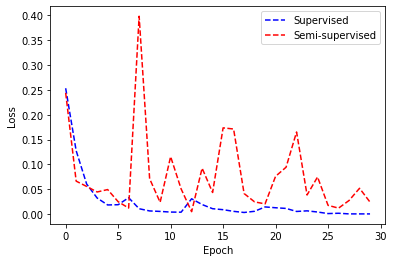

In [ ]:
import matplotlib.pyplot as plt
import os
# Get fully supervised ResNet 18 results  
loss_dir = os.path.join(root_path,'experiments/resnet18/train_on_train/exp1/train_log','lossPerEpoch.txt')
semiloss_dir = os.path.join(root_path,'experiments/semigan/train_on_train/resnet18_discrim/n=265/epochs=30/train_log','D_lossPerEpoch.txt')
with open(loss_dir) as f:
  lines = f.readlines()
  sup_losses = np.array([line.split()[0] for line in lines]).astype(np.float32)
  f.close()
with open(semiloss_dir) as f:
  lines = f.readlines()
  ssup_losses = np.array([line.split()[0] for line in lines]).astype(np.float32)
  ssup_losses = ssup_losses[:-1]
plt.plot(sup_losses,'b--', ssup_losses, 'r--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(('Supervised','Semi-supervised'))
plt.show
#plt.savefig(os.path.join(root_path,'lossCurve_resnetSupVsSemisup.png'))


# Test: Generator
Load pre-trained model and test on a few images.

In [ ]:
from torchvision.utils import save_image

# Assign test dataset and dataloader
is_training = False  # use some image from train dataset to test model
if is_training:
  img_path, csv_path = train_img_path, train_csv_path
else:
  img_path, csv_path = test_img_path, test_csv_path

test_covidx = COVIDx_Dataset(img_path, csv_path, transforms=transform, is_training=is_training)
test_dataloader = torch.utils.data.DataLoader(test_covidx, batch_size=1, shuffle=False, num_workers=num_workers)

# Load model
genpath = os.path.join(train_test_model_dir, 'gen_epoch_200_loss_10.7206.pth') 
gen = Generator()
gen.to(device)
gen.load_state_dict(torch.load(genpath))
gen.eval()

# Create images
z = Variable(torch.cuda.FloatTensor(np.random.normal(0, 1, (1, latent_dim))))
gen_imgs = gen(z)
print(gen_imgs.size())
np_imgs = gen_imgs.detach().cpu().numpy().squeeze()
print(np_imgs.shape)
save_image(gen_imgs.detach(), "image.png", normalize=True)
plt.imshow(np.transpose(np_imgs, (1,2,0)))
plt.show()


NameError: ignored

# Test: Discriminator (classifier) 

Test loop

In [ ]:
def test(model, test_dataloader, file):
  model.eval()
  y_preds, y_trues = [], []
  with torch.no_grad():
    for i, (inputs, labels,_,_) in enumerate(test_dataloader):
      inputs, labels = Variable(inputs), Variable(labels)
      inputs, labels = inputs.to(device), labels.to(device)
      outputs, _ = model(inputs)
      probs = F.softmax(outputs, dim=1).detach().cpu().numpy()
      pred = np.argmax(probs, axis=1)        # get predicted label
      label = labels.detach().cpu().numpy()  # get true label
      y_preds.append(pred)  
      y_trues.append(label)  

    # Now we have the probs and trues list for all test images, we can compute performance metrics
    results = compute_perform_stats(y_preds, y_trues, n_classes)
    acc = np.array(results['accuracy'])
    f1 = np.array(results['f1'])
    recall = np.array(results['recall'])
    precision = np.array(results['precision'])

    print('Mean Accuracy: {:.4f}, Mean F1-score: {:.4f}'.format(acc, np.mean(f1)) )
    print()

    # Now print stats for each class
    print('Normal stats:\n')
    print('\tPrecision: {:.4f}, Recall: {:.4f}, F1-score: {:.4f}\n'.format(precision[0], recall[0], f1[0]))
    print('Pneumonia stats:\n')
    print('\tPrecision: {:.4f}, Recall: {:.4f}, F1-score: {:.4f}\n'.format(precision[1], recall[1], f1[1]))
    print('COVID-19 stats:\n')
    print('\tPrecision: {:.4f}, Recall: {:.4f}, F1-score: {:.4f}\n'.format(precision[2], recall[2], f1[2]))
    
    # Save results to .txt files 
    file.write('Testing results on {} images:\n'.format(len(test_covidx)))
    file.write('\tMean Accuracy:  {} \n'.format(acc))
    file.write('\tPrecision: {} \n'.format(precision))
    file.write('\tRecall:    {} \n'.format(recall))
    file.write('\tF1 score:  {} \n'.format(f1))
    file.write('Classes: normal, pneumonia, COVID-19')
    file.close()
    
    # return test data for plotting performance
    return y_trues, y_preds
    
    

In [ ]:
# Assign test dataset and dataloader
is_training = False 
if is_training:
  img_path, csvpath = train_img_path, train_csv_path
else:
  img_path, csvpath = test_img_path, test_csv_path

test_covidx = COVIDx_test(img_path, csvpath)
test_dataloader = torch.utils.data.DataLoader(test_covidx, batch_size=1, shuffle=True, num_workers=num_workers)

# Load pre-trained model
model_folder = 'resnet18_discrim/n=265/epochs=100/exp2_done/epochs_95to124'
model_weights = 'D_epoch_6_classLoss_0.0100_acc_0.9985_f1_0.9985.pth'
testModelPath = os.path.join(train_train_model_dir, model_folder, model_weights) # complete path to model weights
classifier = covidClassifier(in_channels, n_classes).to(device)
checkpoint = torch.load(testModelPath) 
classifier.load_state_dict(checkpoint['model_state_dict'])
classifier.eval()

covidClassifier(
  (backbone): Sequential(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

In [ ]:
# Create f1 results .txt 
file = open(os.path.join(train_train_model_dir, model_folder, 'results_epoch6.txt'),'w')

# Run a pass of images 
y_trues, y_preds = test(classifier, test_dataloader, file)


Mean Accuracy: 0.9052, Mean F1-score: 0.8617

Normal stats:

	Precision: 0.9079, Recall: 0.9582, F1-score: 0.9324

Pneumonia stats:

	Precision: 0.9059, Recall: 0.8586, F1-score: 0.8816

COVID-19 stats:

	Precision: 0.8649, Recall: 0.6957, F1-score: 0.7711



# Performance plots


Confusion matrix

In [ ]:
import sklearn
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_true=y_trues, y_pred=y_preds)
print(confusion)

[[848  34   3]
 [ 77 510   7]
 [  9  19  64]]


Precision-recall curve

In [ ]:
disp = plot_precision_recall_curve(classifier, X_test, y_test)
disp.ax_.set_title('2-class Precision-Recall curve: '
                   'AP={0:0.2f}'.format(average_precision))


# Grad-CAM results

In [ ]:
# Make new dataloader with custom batch size for retreiving test images for CAM
cam_dataloader = torch.utils.data.DataLoader(test_covidx, batch_size=20, shuffle=True, num_workers=num_workers)
imgs, lbls, ids, filenames = next(iter(cam_dataloader))
outputs, reals = classifier(imgs.to(device))
gt_labels = lbls.detach().cpu().numpy()
pred_labels = np.argmax(F.softmax(outputs,dim=1).detach().cpu().numpy(), axis=1)
print('True labels: '+str(gt_labels))
print('Pred labels: '+str(pred_labels))

# Get class instances 
norm_idx  = np.where(gt_labels==0)
pneum_idx = np.where(gt_labels==1)
cov_idx   = np.where(gt_labels==2)
print('Normal: '+str(norm_idx))
print('Pneumonia: '+str(pneum_idx))
print('COVID: '+str(cov_idx))

# Print filenames for gradcams later
# print('Normal files: '+filenames[norm_idx])
# print('Pneumonia files: '+filenames[pneum_idx])
# print('COVID files: '+filenames[cov_idx])

torch.cuda.empty_cache()


True labels: [0 0 1 0 0 1 2 1 1 0 1 0 0 1 1 1 0 0 1 0]
Pred labels: [0 0 1 0 0 1 2 1 1 0 1 0 0 1 0 1 0 0 1 0]
Normal: (array([ 0,  1,  3,  4,  9, 11, 12, 16, 17, 19]),)
Pneumonia: (array([ 2,  5,  7,  8, 10, 13, 14, 15, 18]),)
COVID: (array([6]),)


PatientID: ANON29
Filename: CR.1.2.840.113564.1722810170.20200403211237078970.1003000225002.png
True class= 2
Pred class= 2
tensor([[-3.2246, -7.7365,  0.3830]], device='cuda:0', grad_fn=<AddmmBackward>)
tensor([[2.6394e-02, 2.8973e-04, 9.7332e-01]], device='cuda:0',
       grad_fn=<SoftmaxBackward>)


/usr/local/lib/python3.6/dist-packages/torch/nn/functional.py:2941: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")


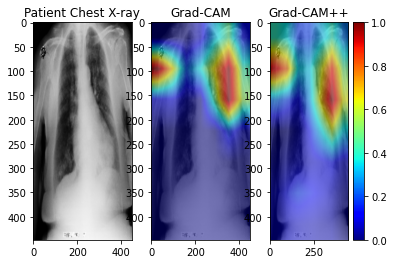

In [ ]:
# Select image n from the dataloader, and send through network to activate neurons in penultimate conv layer
save_cam = False
save_filename = False

n = 4
img = imgs[n,:,:,:].unsqueeze(0).to(device) # get rescaled, ImageNet standardised image from dataloader
lbl, pred_label = gt_labels[n], pred_labels[n] # get nth labels
id, filename = ids[n], filenames[n]            # get nth patients info
print('PatientID: '+str(id))
print('Filename: '+str(filename))
print('True class= '+str(lbl))
print('Pred class= '+str(pred_label))

# if we want to keep this file for running on different models for results  
if save_filename: 
  with open(os.path.join(model_path, 'patient_filenames.txt'), 'a') as filename_txt:
    filename_txt.write('{} {}'.format(filename, lbl) + '\n')
    filename_txt.close()

# Choose layer to get activations from,
if 'vgg' in model_type.lower():
  selected_layer = 'features_42'
elif 'resnet' in model_type.lower():
    selected_layer = 'layer4'
elif 'densenet' in model_type.lower():
    selected_layer = 'features_norm5'

# Initialise GradCAM(++) and pass image through
model_dict = dict(model_type=model_type, arch=model, layer_name=selected_layer, input_size=(224, 224))
gradcam = GradCAM(model_dict)
gradcampp = GradCAMpp(model_dict)
logit = model(img)
mask1, logit1,gradients,activations,weights = gradcam(img, class_idx=pred_label) # get map of predicted class 
mask2, logit2,_ = gradcampp(img, class_idx=pred_label)
prob, index = torch.max(F.softmax(logit2,dim=1), 1)
print(logit)
print(F.softmax(logit2,dim=1))

# Manually get the original images loaded by dataloader for using in gradcam 
orig_img_path = os.path.join(img_path, str(filename)) # use img_path from above, and get image with that filename
input_img = imread(orig_img_path)
# Extract original image and resize 
orig_img = cv2.resize(input_img,(input_resize,input_resize))
# Scale pixels between [0,1], and send to np.stacking (see Loading the data)
orig_img = _convertToRGB(orig_img/255) 

# make heatmap from mask and synthesize saliency map using heatmap and the original image 
heatmap1, cam_result1 = visualize_cam(mask1, torch.from_numpy(orig_img).permute(2,0,1).unsqueeze(0))
heatmap2, cam_result2 = visualize_cam(mask2, torch.from_numpy(orig_img).permute(2,0,1).unsqueeze(0))
gradcam_np, gradcampp_np = cam_result1.permute(1,2,0).numpy(), cam_result2.permute(1,2,0).numpy()

# resize images to double input_resize
orig_img = cv2.resize(orig_img,(input_resize*2,input_resize*2))
gradcam_np = cv2.resize(gradcam_np,(input_resize*2,input_resize*2))
gradcampp_np = cv2.resize(gradcampp_np,(input_resize*2,input_resize*2))

# Show cam results
plt.subplot(1, 3, 1).set_title('Patient Chest X-ray')
plt.imshow(orig_img, vmin=0, vmax=1, cmap='jet', aspect='auto')
plt.subplot(1, 3, 2).set_title('Grad-CAM')
plt.imshow(gradcam_np, vmin=0, vmax=1, cmap='jet', aspect='auto')
plt.subplot(1, 3, 3).set_title('Grad-CAM++')
plt.imshow(gradcampp_np, vmin=0, vmax=1, cmap='jet', aspect='auto')
plt.colorbar()

# Get folder name from pathology mapping based on prediction lbl
pathology_mapping = { 'normal': 0, 'pneumonia': 1, 'covid': 2 } 
camFolder = list(pathology_mapping.keys())[list(pathology_mapping.values()).index(lbl)]

# Save images as .png to correct folder
if save_cam:
  orig_img_result  = Image.fromarray((orig_img*255).astype(np.uint8)).convert('RGB')
  gradcam_result   = Image.fromarray((gradcam_np*255).astype(np.uint8)).convert('RGB')
  gradcampp_result = Image.fromarray((gradcampp_np*255).astype(np.uint8)).convert('RGB')
  orig_img_result.save(os.path.join(train_train_model_dir,  model_folder, ('epoch30_results/{}').format(camFolder),  ('{}_input_gt={}_pred={}.png'.format(id,lbl,pred_label))))
  gradcam_result.save(os.path.join(train_train_model_dir,   model_folder, ('epoch30_results/{}').format(camFolder),  ('{}_gradcam_gt={}_pred={}.png'.format(id,lbl,pred_label))))
  gradcampp_result.save(os.path.join(train_train_model_dir, model_folder, ('epoch30_results/{}').format(camFolder),  ('{}_gradcam++_gt={}_pred={}.png'.format(id,lbl,pred_label))))

/usr/local/lib/python3.6/dist-packages/torch/nn/functional.py:2941: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")


tensor([[9.8939e-01, 8.3907e-05, 1.0522e-02]], device='cuda:0',
       grad_fn=<SoftmaxBackward>)


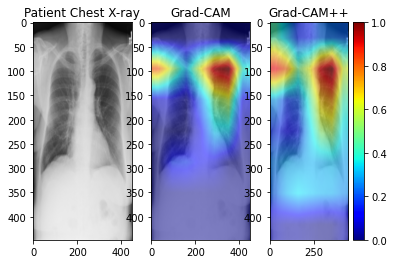

In [ ]:
# Transforms for test images
testTransforms = transforms.Compose([
              Xray_resize(),
              transforms.ToTensor(), 
              transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),                      
])

# Get a GradCAM saliency map on the class index of interest
csvfile = _process_txt_file(os.path.join(model_path, 'patient_filenames.txt'))
sample = csvfile[13].split()
patientFile = sample[0]
img = imread(os.path.join(img_path, patientFile))
img = _config_images(img)
img_tensor = testTransforms(img).unsqueeze(0).cuda()
id = sample[1]
lbl = int(sample[2])

# Run image through model
logit = model(img_tensor)
model_dict = dict(model_type=model_type, arch=classifier, layer_name='layer4', input_size=(224, 224))
gradcam = GradCAM(model_dict)
gradcampp = GradCAMpp(model_dict)
mask1, logit1,gradients,activations,weights = gradcam(img_tensor, class_idx=lbl) # get map of predicted class 
mask2, logit2,_ = gradcampp(img_tensor, class_idx=lbl)
prob, index = torch.max(F.softmax(logit2,dim=1), 1)
print(F.softmax(logit2,dim=1))

# Extract original image and resize 
orig_img = cv2.resize(img,(GAN_imgresize,GAN_imgresize))
# Scale pixels between [0,1], and send to np.stacking (see Loading the data)
orig_img = _config_images(orig_img/255) 

# make heatmap from mask and synthesize saliency map using heatmap and the original image 
heatmap1, cam_result1 = visualize_cam(mask1, torch.from_numpy(orig_img).permute(2,0,1).unsqueeze(0))
heatmap2, cam_result2 = visualize_cam(mask2, torch.from_numpy(orig_img).permute(2,0,1).unsqueeze(0))
gradcam_np, gradcampp_np = cam_result1.permute(1,2,0).numpy(), cam_result2.permute(1,2,0).numpy()

# resize images to double input_resize
orig_img = cv2.resize(orig_img,(GAN_imgresize*2,GAN_imgresize*2))
gradcam_np = cv2.resize(gradcam_np,(GAN_imgresize*2,GAN_imgresize*2))
gradcampp_np = cv2.resize(gradcampp_np,(GAN_imgresize*2,GAN_imgresize*2))

# Show cam results
plt.subplot(1, 3, 1).set_title('Patient Chest X-ray')
plt.imshow(orig_img, vmin=0, vmax=1, cmap='jet', aspect='auto')
plt.subplot(1, 3, 2).set_title('Grad-CAM')
plt.imshow(gradcam_np, vmin=0, vmax=1, cmap='jet', aspect='auto')
plt.subplot(1, 3, 3).set_title('Grad-CAM++')
plt.imshow(gradcampp_np, vmin=0, vmax=1, cmap='jet', aspect='auto')
plt.colorbar()
# plt.savefig('epoch30_results/{}').)

# Get folder name from pathology mapping based on prediction lbl
pathology_mapping = { 'normal': 0, 'pneumonia': 1, 'covid': 2 } 
pathology = list(pathology_mapping.keys())[list(pathology_mapping.values()).index(lbl)]

# Save images as .png to correct folder
orig_img_result  = Image.fromarray((orig_img*255).astype(np.uint8)).convert('RGB')
# gradcam_result   = Image.fromarray((gradcam_np*255).astype(np.uint8)).convert('RGB')
gradcampp_result = Image.fromarray((gradcampp_np*255).astype(np.uint8)).convert('RGB')
orig_img_result.save(os.path.join(train_train_model_dir,  model_folder, 'epoch6_results/sgan_paper_figs',  ('{}_input_{}.png'.format(id, pathology))))
# gradcam_result.save(os.path.join(train_train_model_dir,   model_folder, 'epoch30_results/paper_figs',  ('{}_gradcam_gt={}_pred={}_{}'.format(id,lbl,pred_label,filename))))
gradcampp_result.save(os.path.join(train_train_model_dir, model_folder, 'epoch6_results/sgan_paper_figs',  ('{}_gradcam++_{}_{}.png'.format(id,model_type,pathology))))

# Old codes

In [ ]:
##########################################################################
#                           Semi-supervised model  
# Useful for:
#        - learning what a 'healthy' CXR/CT lung image looks like.
#        - leveraging limited labelled data available, whilst at the same time 
#          learning from unlabelled data. 
#        - dealing with domain shift/generalisation issues between datasets.
#        
# Idea:
#        - since we have limited data, we can train a model to learn 
#          what makes a healthy CXR/CT image so that when an abnormal image 
#          comes in, it can classify it as 'non-healthy'. This is for the purely unsupervised
#          case.
#        - however, this ability will be enhanced with a semi-supervised approach since
#          there are labelled data available. Thus, the idea is to leverage the information 
#          from the known cases, whilst teaching the model to learn what constitutes a COVID patient
#          scan on its own. This has been shown to give similar performance to fully supervised models,
#          in spite of far less training data [1] which makes it ideal for this work.
#        - in addition, we can also train the model to deal with domain-shift/generalisation issues
#          by using an adversarial loss from the unsupervised output layer. As a result, the model will become more robust to
#          new test images from a different domain. This has been shown to far outperform
#          supervised models on the same task [2].
#        
# [1] Yi et al (2019): GANs in medical imaging: a review. Medical Image analysis; 58 (101522).
#        
# [2] Madani et al (2018): SEMI-SUPERVISED LEARNING WITH GENERATIVE ADVERSARIAL NETWORKS FOR 
#                          CHEST X-RAY CLASSIFICATION WITH ABILITY OF DATA DOMAIN ADAPTATION.
##########################################################################
  
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        
        # Class label embedding: use as conditional input to guide image generation 
        self.label_emb = nn.Embedding(n_classes, latent_dim)
        self.fm_max = 512
        self.filter_size = [self.fm_max, self.fm_max//2, self.fm_max//4, self.fm_max//8, self.fm_max//16]
        self.nconv_layers = 4
        self.init_size = GAN_imgresize // 2**self.nconv_layers  # 128/2**4=8 Initial size before upsampling

        # Take [100xbs] array of noise (from normal dist.), send through linear layer to map as 
        # [bs, 512*8*8] = [bs, 32768].
        self.l1 = nn.Linear(latent_dim, self.fm_max * self.init_size ** 2)
        
        # Start convolution blocks
        self.conv_blocks = nn.Sequential(
            # BnUp: in=[bs, 512, 8, 8] -> out=[bs, 512, 16, 16]    
            nn.BatchNorm2d(self.filter_size[0]),
            nn.Upsample(scale_factor=2), 
            # ConvBnReluUp block 1: in=[bs, 512, 16, 16] -> out=[bs, 256, 32, 32]
            nn.Conv2d(self.filter_size[0], self.filter_size[1], kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(self.filter_size[1], 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),
            # ConvBnReluUp block 2: in=[bs, 256, 32, 32] -> out=[bs, 128, 64, 64]
            nn.Conv2d(self.filter_size[1], self.filter_size[2], kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(self.filter_size[2], 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),
            # ConvBnReluUp block 3: in=[bs, 128, 64, 64] -> out=[bs, 64, 128, 128]
            nn.Conv2d(self.filter_size[2], self.filter_size[3], kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(self.filter_size[3], 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),
            # ConvTanh: in=[bs, 64, 128, 128] -> out=[bs, img_channels, 128, 128] -> to discriminator  
            nn.Conv2d(self.filter_size[3], in_channels, kernel_size=3, stride=1, padding=1),
            nn.Tanh(),
        )

    def forward(self, noise):
        # send noise through linear layer, and reshape from [bs, 32768] to [bs, C=512, H=8, W=8]
        noise_input = self.l1(noise) 
        noise_input = noise_input.view(noise_input.shape[0], self.fm_max, self.init_size, self.init_size) 
        #option: include class labels for conditional info:
        #send labels through embedding layer, and reshape to same size as noise_input
        #label_input = self.label_emb(labels)
        #concatenate both label and noise input to form complete generator input
        #gen_input = noise_input  torch.cat((label_input, noise_input), -1) 

        # now send tiny image of noise through generator to produce gen_img
        img = self.conv_blocks(noise_input)
        return img 

# Designed with separate output layer approach, where one layer deals with predicting the likelihood
# of the image being real (unsupervised branch), and the other deals with predicting the K class of the 
# images well, as well as whether it is a generated image or not (i.e. total=K+1 classes).
# There is another implementation proposed by Goodfellow that uses a stacked approach, but I've 
# done this first just to get it working. 
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        self.nconvs = 4
        self.fm_max = 512
        self.filter_size = [self.fm_max, self.fm_max//2, self.fm_max//4, self.fm_max//8, self.fm_max//16] # [512, 256, 128, 64, 32]

        def discriminator_block(in_filters, out_filters, bn=True):
            block = [nn.Conv2d(in_filters, out_filters, kernel_size=3, stride=2, padding=1), nn.LeakyReLU(0.2, inplace=True), nn.Dropout2d(0.25)]
            if bn:
                block.append(nn.BatchNorm2d(out_filters, 0.8))
            return block

        self.conv_blocks = nn.Sequential(
            *discriminator_block(in_channels, self.filter_size[4], bn=False),       # in=[bs, 3, 128, 128], out=[bs, 32, 64, 64]
            *discriminator_block(self.filter_size[4], self.filter_size[3]),         # in=[bs, 32, 64, 64],  out=[bs, 64, 32, 32]
            *discriminator_block(self.filter_size[3], self.filter_size[2]),         # in=[bs, 64, 32, 32],  out=[bs, 128, 16, 16]
            *discriminator_block(self.filter_size[2], self.filter_size[1]),         # in=[bs, 128, 16, 16], out=[bs, 256, 8, 8]
        )

        # The height and width of downsampled image after nconvs convolution blocks
        ds_size = GAN_imgresize // 2 ** self.nconvs # 128 // 2*4 = 8

        self.fc = nn.Linear(self.filter_size[1] * ds_size ** 2, n_classes)

    def custom_activation(self,output):
        # Use trick from Goodfellow et al to prevent creating two branches of supervised network.
        # Take unnormalised activations (pre softmax) from fc output (K classes), and normalise
        # them to values between [0,1] for real/fake prediction.
        Zx = torch.sum(torch.exp(output), dim=1)
        return Zx / (Zx + 1.0)

    def forward(self, img):
        # Output from convolution layers
        out = self.conv_blocks(img)         # conv_blocks output: [bs, 256, 8, 8]
        out = out.view(out.shape[0], -1)    # flattened features: [bs, 16384] (16384=256*8*8) 
        out = self.fc(out)                  # fc output: [bs, n_classes]

        # Now compute supervised and unsupervised outputs
        # supervised_output = nn.functional.softmax(out, dim=1) # class predictions (probs for each class -> CE loss)
        # Change: dont use softmax here since nn.CrossEntropyLoss does this!
        supervised_output = out # raw class predictions: 
        unsupervised_output = self.custom_activation(out)     # real/fake prob -> BCE loss

        return supervised_output, unsupervised_output

classifier = Discriminator()  
classifier.cuda()      


In [ ]:
""" Define testing loop """
def test(discriminator, test_dataloader):

  acc_list, f1_list = [], []
  class_preds, class_gts = [], [] 
  with torch.no_grad():
    for i, (inputs, labels, _) in enumerate(test_dataloader):
      inputs, labels = Variable(inputs), Variable(labels)
      inputs, labels = inputs.to(device), labels.to(device)
      _, preds  = discriminator(inputs)
      y_probs = F.softmax(preds, dim=1).detach().cpu().numpy() # convert [1, 4] raws into [1,4] probs
      y_preds = np.argmax(y_probs, axis=1) # get the index of highest prob -> predicted class
      y_gt = labels.detach().cpu().numpy() # get true class label
      class_preds.append(y_preds)          # store predicted label into class_preds 
      class_gts.append(y_gt)
    #print(class_preds) # list of pred labels
    #print(class_gts) # list of true labels
    stats = compute_perform_stats(class_preds, class_gts) # take list of pred and gt labels and compute stats 
    d_acc = stats['accuracy']
    print(d_acc)        
  return class_preds, class_gts
   
      
      #y_trues = labels.detach().cpu().numpy()
      #results = compute_perform_stats(y_probs, y_trues)
      #accuracy_score, f1_score = results['accuracy'], results['f1']
      #cc_list.append(accuracy_score)
      #f1_list.append(f1_score)
      #file.write(str(f1_scores))
    #file.close()
    # Average/std results over all images in test dataset (or batch of test images)
    #acc_batch = np.mean(acc_list)  
    #f1_batch = np.mean(f1_list)
    #print('Accuracy: {:.4f}, F1-score: {:.4f}'.format(acc_batch, f1_batch))

# Assign test dataset and dataloader
is_training = test  # use some image from train dataset to test model
if is_training:
  img_path, csv_path = train_img_path, train_csv_path
else:
  img_path, csv_path = test_img_path, test_csv_path

test_covidx = COVIDx_test(img_path, csv_path)
test_dataloader = torch.utils.data.DataLoader(test_covidx, batch_size=10, shuffle=True, num_workers=num_workers)

# Discriminator
dispath = os.path.join(train_train_model_dir, '') 
classifier = Discriminator()
classifier.to(device)
classifier.load_state_dict(torch.load(dispath))
classifier.eval()

# Run test loop
preds, labels = test(disc, test_dataloader)


In [ ]:
 """ 
old way for setting up discriminator outputs: two separate 'layers'
Output layers:
    adv_layer: in=[bs, 256, 8, 8] -> .view[-1] -> [bs, 16384] -> out[bs, 1],   where out is prob of real/fake 
    aux_layer: in=[bs, 256, 8, 8] -> .view[-1] -> [bs, 16384] -> out[bs, 3+1], where out is class outputs (3) + real/fake (1) value
"""
# # Layer for discriminating between real and fake images
# self.discrim_layer = nn.Sequential(nn.Linear(self.filter_size[1] * ds_size ** 2, 1), nn.Sigmoid())  # real/fake prob: generator output (unsup mode): BCELoss expected sigmoid probs

# # Layer for classifying image as normal, pneum or covid + real/fake (since generator)
# self.class_layer   = nn.Sequential(nn.Linear(self.filter_size[1] * ds_size ** 2, n_classes + 1))#, nn.Softmax(dim=1))  # K+1 probs: classifier outputs (sup mode): nn.CEloss expected raw scores


In [ ]:
# Standard packages for reading/processing data 
import numpy as np
import os
import cv2
from PIL import Image
import skimage
from skimage.io import imread

# PyTorch libraries
import torch
import torch.nn.functional as F
import torch.utils.data as data
from torchvision import transforms

##########################################################################
#                           X-ray data reader  
##########################################################################

class COVIDx_Dataset(data.Dataset):
    def __init__(
            self,
            image_dir,
            txt_file,
            transforms, 
            is_training,
            augmentation=None
            ):
        
        """ Initialise some things """
        self.imgpath = image_dir
        self.csv_file = _process_txt_file(txt_file)       # read .txt file containing image info.
        self.labels = _convert_labels(self.csv_file)  # array of one hot encoded labels: processed here for faster indexing with dataloader
        self.is_training = is_training
        self.transforms = transforms
        self.n_classes = n_classes
        self.n_channels = in_channels
        self.augmentation = augmentation
        self.MAXVAL = 255
        
    def __len__(self):
        return len(self.csv_file)
    
    def __getitem__(self, idx):

        if self.is_training:
            folder = 'train'
        else:
            folder = 'test'
            
        """ Get image using info from csv file """
        samples = self.csv_file[idx].split()                # get full line of data at row idx 
        filename = samples[1]                               # get filename from 2nd column
        img_path = os.path.join(self.imgpath, filename)     # get image with that filename
        image = imread(img_path)

        """ Some images are weird shapes (e.g. [30].shape=(1920,1000,4)) 
            Remove colour channels and restack to get in RGB form for ResNet.
        """
        if len(image.shape) != 3:                               # if image is grayscale (H,W)
            image = np.stack((image, image, image), axis=2)     # stack to give new shape: (H, W, 3)
        elif image.shape[2] == 4:                               # else, if image is RGBA (H,W,4)
            imgray = image[:, :, 0]                             # remove colour channel
            image = np.stack((imgray, imgray, imgray), axis=2)  # new shape: (H, W, 3)

         # Apply transforms and convert to torch.FloatTensor (or FloatCudaTensor if cuda)
        if self.transforms:  
            images = self.transforms(image)
        #images = torch.from_numpy(images).float().permute(2, 0, 1)

        """ Get labels """
        labels = self.labels[idx]
                
        return images, labels, filename
    

##########################################################################
#                           Helper functions  
##########################################################################    
        
""" Convert string labels to OHE versions """ 
# Take in csv/txt file, split, and extract 3rd column (which contains the str labels of pathologies)
# Next, encode these strings as integers using pathology_mapping. 
# Send to _one_hot_encode(). 
# Return OHE labels to __init__().
def _convert_labels(csvfile):
    int_labels = _get_int_labels(csvfile)
    ohe_labels = _one_hot_encode(int_labels)
    return int_labels # choose to return either int_labels for in-built loss (here: nn.CrossEntropyLoss), or ohe_labels for custom loss.

""" Take in .txt file, split apart, and return 3rd column as integer labels """
def _get_int_labels(csvfile):
    pathology_mapping = { 'normal': 0, 'pneumonia': 1, 'COVID-19': 2 } # assign integers to pathology labels
    int_labels = np.empty(len(csvfile)).astype(np.int)  # initialise storage array
    for i, patient_i in enumerate(csvfile):             # for each patient in our file list, get index i and string of info for that patient
        patient_list = patient_i.split()                # extract ith patient info as a list using split()
        pathology = patient_list[2]                     # get pathology name (in 3rd column)
        int_labels[i] = pathology_mapping[pathology]    # now map that name to its corresponding int_label
    return int_labels                                   # return int_labels for all pathologies

""" Return one hot encoded equivalents of integer labels from _get_int_labels(). """
def _one_hot_encode(int_labels):
    labels = torch.from_numpy(int_labels)
    return F.one_hot(labels, n_classes)

""" Read .txt file and store as list """
def _process_txt_file(file):
    with open(file, 'r') as fr:
        files = fr.readlines()
    return files

"""Scales images to be roughly [-1024 1024]."""
def normalize(sample, maxval):
    sample = (2 * (sample.astype(np.float32) / maxval) - 1.) * 1024
    return sample

""" For resizing the image without needing to convert to PIL image (as with torchvision.transforms.Resize()) """
class Xray_resize(object):
    def __init__(self):
      self.size = GAN_imgresize
    def __call__(self, img):
      return cv2.resize(img, (self.size, self.size))

""" Does the np.stacking offline so its quicker for the dataloader to retrieve images """
#def _config_images(img_path):
#   if len(image.shape) != 3:                             # if image is grayscale (H,W)
#     image = np.stack((image, image, image), axis=2)     # stack to give new shape: (H, W, 3)
#   elif image.shape[2] == 4: 
#     imgray = image[:, :, 0]                             # remove colour channel
#     image = np.stack((imgray, imgray, imgray), axis=2)  # new shape: (H, W, 3)
#  return 

# Given a class-balanced dataset, and the number of images per class we want to
# train the model on, return a labelled subset of the balanced_dataset according 
# to patient IDs. (to prevent duplicates)
def getLabelledData(balanced_dataset, n_per_class=50, n_classes=3):
    X, y, ids = balanced_dataset # only use ids to select covid images (to avoid duplicates in unlabelled dataset)
    X_list, y_list = list(), list()
    rng = default_rng()
    for c in range(n_classes):
      # get row indices where class i occurs 
      rows = np.where(y==c)[0]
      # now extract files and ids at those rows
      X_with_class = [X[r] for r in rows]
      ids_with_class = [ids[r] for r in rows]
      if c!=2:   # if we're not on COVID class, patients dont have multiple scans, so
        # choose random instances 
        ix = rng.choice(range(len(X_with_class)), n_per_class, replace=False) 
        # add to list
        [X_list.append(X_with_class[j]) for j in ix]
        [y_list.append(c) for j in ix]
      # otherwise, we need to make sure we select images based on patient ID
      # so that we dont have duplicates in labelled and unlabelled datasets.
      else: 
        # randomly select indices
        ix = rng.choice(range(len(X_with_class)), n_per_class, replace=False)
        # get the covid patient ids at those random indices
        poss_lbl_ids = [ids_with_class[j] for j in ix] # get possible labelled ids from random selection
        print(poss_lbl_ids) 
        count=0 # initialise image counter
        used_ids = [] # create list for storing patient IDs already included in dataset -> failsafe against duplicates
        for i in range(n_per_class):             # for 1:n_per_class patients 
          test_id = poss_lbl_ids[i]               # extract an id
          if i>0 and test_id in used_ids:        # v2 check: ensures randomness, rather than checking previous id in an ordered list!!
            print('already included patient {}s data. go to next patient'.format(test_id))
            continue                             # -> go to next patient
          n_ids = ids_with_class.count(test_id)               # count how many times this id occurs in ids_with_class          
          if n_ids+count < n_per_class:                # if we are still under the max number of images
            count+=n_ids                                      # increment counter 
            used_ids.append(test_id)                    # add id to list of patients used in dataset for checking duplicate IDs
            print(count)
            id_rows = np.where(np.asarray(ids_with_class)==np.asarray(test_id))[0]    # get the rows where that id occurs
            [X_list.append(X_with_class[r]) for r in id_rows] # append X_list with images for that patient id
            [y_list.append(c) for r in id_rows]               # append y_list with labels for that patient id
            continue
          elif n_ids+count > n_per_class:              # if by adding these images to X_list will exceed our limit 
            print('adding patient {}s images would exceed {} image limit. go to next patient.'.format(test_id,n_per_class))
            continue                                          # -> go to next patient
          elif (n_ids+count)==n_per_class:             # if, by adding these images we have met our max limit, leave loop
            count+=n_ids
            id_rows = np.where(np.asarray(ids_with_class)==np.asarray(test_id))[0]    # get the rows where that id occurs
            [X_list.append(X_with_class[r]) for r in id_rows] # append X_list with images for that patient id
            [y_list.append(c) for r in id_rows]               # append y_list with labels for that patient id
            # Summarise:
            print('====================')
            print('count={}. Finished selecting labelled data.'.format(count))
            print('*****')
            print('Patients included in labelled dataset: {}'.format(used_ids))
            break
    return np.asarray(X_list), np.asarray(y_list), np.asarray(used_ids)


In [ ]:
# Standard packages for reading/processing data 
import numpy as np
from numpy.random import default_rng
import os
import cv2
from PIL import Image
import skimage
from skimage.io import imread
from imgaug import augmenters as iaa

# PyTorch libraries
import torch
import torch.nn.functional as F
import torch.utils.data as data
from torchvision import transforms

##########################################################################
#                           X-ray data reader  
##########################################################################

class COVIDx_Dataset(data.Dataset):
    def __init__(
            self,
            image_dir,
            txt_file,
            n_per_class,
            train=True, 
            labelled=True,
            transforms=True
        ):
        
        """ Initialise some things """
        self.imgpath = image_dir
        self.transforms = transforms
        self.n_channels = in_channels
        self.train = train
        self.labelled = labelled

        """ For training mode (i.e class balancing) """
        # Load in spreadsheet of COVIDx dataset (txt_file) and balance the classes 
        balanceData = balanceToCovid(txt_file)   # initialise with spreadsheet
        self.files, self.lbls, self.ids = balanceData()         # now call the function to return the balanced dataset
        balanced_dataset = self.files, self.lbls, self.ids

        # User balanced data and n_per_class (user input) to 
        # get both labelled and unlabelled datasets. 
        # self.labelled_dataset, self.unlabelled_dataset = get_SGAN_data(self.balanced_dataset, n_per_class)
        self.X_lbl, self.y_lbls, self.X_unlbl = get_SGAN_data(balanced_dataset, n_per_class)

        """ For testing mode """
        self.csv_file = _process_txt_file(txt_file)   # read .txt file containing image info.
        self.labels = _convert_labels(self.csv_file)  # array of one hot encoded labels: processed here for faster indexing with dataloader
  
    def __len__(self):
        return len(self.files)
    
    def _transformImage(self,img):
        transform = transforms.Compose([
                  Xray_resize(),                            
                  transforms.ToTensor(), 
                  transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ]) 
        return transform(img)

    def __getitem__(self, idx):
        
        # if we are in training mode,
        if self.train:
          if self.labelled: # run this section if we are using label_dataloader
            # Get batch of labelled real images (s) from dataloader
            file_s = self.X_lbl[idx] # return files with label
            img_path = os.path.join(self.imgpath, file_s)    
            image_s = imread(img_path)
            imgs_sup = _config_images(image_s) 
            lbls = self.y_lbls[idx]       
            if self.transforms:  
              imgs_sup = self._transformImage(imgs_sup)
            return [imgs_sup, lbls]
          else: # otherwise, run if using unlabelled_dataloader
            # Get batch of unlabelled real images (us) from dataloader
            file_us = self.X_unlbl[idx]           # return files without label
            img_path = os.path.join(self.imgpath, file_us)    
            image_us = imread(img_path)
            imgs_unsup = _config_images(image_us)           
            if self.transforms:  
              imgs_unsup = self._transformImage(imgs_unsup)
            return imgs_unsup

        else: # otherwise, we are in testing mode so
          samples = self.csv_file[idx].split()                # get full line of data at row idx 
          filename = samples[1]                               # get filename from 2nd column
          img_path = os.path.join(self.imgpath, filename)     # get image with that filename
          image = imread(img_path)
          imgs = _config_images(image)
          if self.transforms:
            imgs = self._transformImage(imgs)
          labels = self.labels[idx]
          return imgs, labels, filename # return filename for GradCAM
    
##########################################################################
#                           Helper functions  
##########################################################################    

""" Convert string labels to OHE versions """ 
# Take in csv/txt file, split, and extract 3rd column (which contains the str labels of pathologies)
# Next, encode these strings as integers using pathology_mapping. 
# Send to _one_hot_encode(). 
# Return OHE labels to __init__().
# choose to return either int_labels for in-built loss (here: nn.CrossEntropyLoss), or ohe_labels for custom loss.
def _convert_labels(csvfile):
    int_labels, ids = _get_int_labels(csvfile)
    ohe_labels = _one_hot_encode(int_labels)
    return int_labels, ids # return chosen label format along with patient ids for counting later

""" Take in .txt file, split apart, and return 3rd column as integer labels """
def _get_int_labels(csvfile):
    pathology_mapping = { 'normal': 0, 'pneumonia': 1, 'COVID-19': 2 } # assign integers to pathology labels
    int_labels = np.empty(len(csvfile)).astype(np.int)  # initialise storage array
    ids = [] 
    for i, patient_i in enumerate(csvfile):             # for each patient in our file list, get index i and string of info for that patient
        patient_list = patient_i.split()                # extract ith patient info as a list using split()
        pathology = patient_list[2]                     # get pathology name (in 3rd column)
        int_labels[i] = pathology_mapping[pathology]    # now map that name to its corresponding int_label
        # Count patients: use id since some patients have multiple images
        ids.append(patient_list[0])   
    return int_labels, ids  # return int_labels for all pathologies

""" Return one hot encoded equivalents of integer labels from _get_int_labels(). """
def _one_hot_encode(int_labels):
    labels = torch.from_numpy(int_labels)
    return F.one_hot(labels, n_classes)

""" Does the np.stacking offline so its quicker for the dataloader to retrieve images """
def _config_images(image):
    if len(image.shape) < 3:                              # if image is grayscale (H,W)
      image = np.stack((image, image, image), axis=2)     # stack to give new shape: (H, W, 3)
    elif image.shape[2] == 4: 
      imgray = image[:, :, 0]                             # remove colour channel
      image = np.stack((imgray, imgray, imgray), axis=2)  # new shape: (H, W, 3)
    return image

""" Read .txt file and store as list """
def _process_txt_file(file):
    with open(file, 'r') as fr:
        files = fr.readlines()
    return files

""" For resizing the image without needing to convert to PIL image (as with torchvision.transforms.Resize()) """
class Xray_resize(object):
    def __init__(self):
      self.size = GAN_imgresize
    def __call__(self, img):
      return cv2.resize(img, (self.size, self.size))

##########################################################################
#     Functions for balancing the dataset relative to COVID sample size
########################################################################## 
class balanceToCovid(data.Dataset):
    def __init__(self, csv_path):
        self.csvfile = _process_txt_file(csv_path) 
        self.labels, self.ids = _convert_labels(self.csvfile)
        self.n_covids = count_covids(self.labels)
        normal_files, normal_ids = [], []
        pneum_files, pneum_ids = [], []
        covid_files, covid_ids = [], []
        y = self.labels
        for j in range(len(y)):
          if y[j]==0: # if the label at row j is 'normal'
            normal_files.append(self.csvfile[j].split()[1])  # append normal_files with filename at that row 
            normal_ids.append(self.ids[j])                   # append with ids
          elif y[j]==1: # if the label at row j is 'pneum'
            pneum_files.append(self.csvfile[j].split()[1])
            pneum_ids.append(self.ids[j])                   # append with ids
          elif y[j]==2: # if the label at row j is 'covid'
            covid_files.append(self.csvfile[j].split()[1]) 
            covid_ids.append(self.ids[j])                   # append with ids

        # Store files as separate keys in a dict()
        self.all_files = {'normal': normal_files, 'pneum': pneum_files, 'covid': covid_files}
        self.all_ids = {'normal': normal_ids, 'pneum': pneum_ids, 'covid': covid_ids}
        self.n_files = [len(self.all_files[x]) for x in ['normal', 'pneum', 'covid']]
        
    def __call__(self):  
        # clunky way: 
        # Create lists for storing randomly selected 265 files of each class, 
        # and add all lists together at the end to form our balanced dataset.
        # TODO: there will be a slicker way to do this, but get it working first.
        x_n = []
        x_p = []
        id_n = []
        id_p = []
        id_c = []
        y_list = []
        rng = default_rng()
        for i in range(n_classes):
          rand_idx = rng.choice(range(self.n_files[i]), self.n_covids, replace=False)  # choose random instances
          if i==0:
            [x_n.append(self.all_files['normal'][j]) for j in rand_idx]
            [id_n.append(self.all_ids['normal'][j]) for j in rand_idx]
          elif i==1:
            [x_p.append(self.all_files['pneum'][j]) for j in rand_idx]
            [id_p.append(self.all_ids['pneum'][j]) for j in rand_idx]
          X_list = x_n + x_p + self.all_files['covid']   # all filenames
          y_list = np.concatenate((np.zeros(self.n_covids),np.ones(self.n_covids),np.full(self.n_covids,2)), axis=None) 
          id_list = id_n + id_p + self.all_ids['covid']  # all ids
        return X_list, y_list.astype(int), id_list

def countPatients(ids):
    patientCount = 0
    for i in range(0, len(ids)):
        if i==0:
            patientCount += 1
            continue
        if ids[i]==ids[i-1]:
            continue
        else: 
            patientCount += 1
    return patientCount

def count_covids(labels):
    n_covids = 0
    for (i, y) in enumerate(labels):
        if y == 2:
            n_covids += 1 # only count covid images
        else:
            continue
    return n_covids

##########################################################################
#    Function for taking in user specified number of images/class
#    and returning labelled and unlabelled subsets of our balanced
#    COVIDx dataset.
########################################################################## 
# Algorithm for selecting labelled/unlabelled dataset:
        # given a balanced dataset, return labelled data with N samples per class (user input) with no duplicates. 
        # for each class (normal,pneum,covid):
        #   find the rows in balanced_dataset that have that class label 
        #   extract all images and ids at those rows (265 per class)
        #   # Extracting N samples stage
        #   if class isnt covid:
        #     no duplicates/multiple scans, 
        #     so select N random indices between 0 and 265
        #     extract all these images/labels and add to our labelled dataset
        #     loop until all N norm and pneum data added to list (len=2N)
        #   else we are on covid class:
        #     have duplicates/multiple scans -> need to select N images based on patient IDs
        #     set N as limit, and use IDs to extract all images of each patient,
        #     randomly select row indices, 
        #     extract patient IDs at those rows -> pick one at a time (test_id),
        #     v1.<order IDs to allow for duplicate checks> ===> BAD!!!: never select images at end of list ==> not truly random
        #     v2.<check to make sure we havent already added this patients data>,
        #       if true:
        #         already included this patients data -> go to next patient id,
        #       else:
        #         using id, count how many images that patient has
        #        <check if including this patient's images will exceed N>
        #       if not: 
        #         increment counter,
        #         add id to used_ids list for duplicate checks,
        #         add images and labels to labelled dataset,
        #       if true:
        #         too many images -> try next patient,   
        #       iterate through patients until N is reached.          
        #       when counter==N -> break
        #       len(labelled dataset) now == 3N
        # finished. 
# Given a class-balanced dataset, and the number of images per class we want to
# train the model on (user input), return labelled and unlabelled subsets of the balanced_dataset according 
# to patient IDs. (to prevent duplicates).
def get_SGAN_data(balanced_dataset, n_per_class, n_classes=3):
    X, y, ids = balanced_dataset # only use ids to select covid images (to avoid duplicates in unlabelled dataset)
    X_lbl, y_lbl = list(), list() # lists for storing labelled images
    X_unlbl = list()              # list for storing unlabelled images
    rng = default_rng()
    for c in range(n_classes):
      # get row indices where class i occurs 
      rows = np.where(y==c)[0]
      # now extract files and ids at those rows
      X_with_class = [X[r] for r in rows]
      ids_with_class = [ids[r] for r in rows]
      if c!=2:   # if we're not on COVID class, patients dont have multiple scans, so
        # choose random row instances for labelled data
        ilx = rng.choice(range(len(X_with_class)), n_per_class, replace=False) 
        # add to labelled list
        [X_lbl.append(X_with_class[j]) for j in ilx]
        [y_lbl.append(c) for j in ilx]
        # now use ilx to get indices not included in labelled dataset
        iux = np.setdiff1d(range(len(X_with_class)), ilx) # find elements in range(265) NOT in ilx
        # add to unlabelled list
        [X_unlbl.append(X_with_class[j]) for j in iux]
      # otherwise, we need to make sure we select images based on patient ID
      # so that we dont have duplicates in labelled and unlabelled datasets.
      else: 
        # randomly select indices
        ilx = rng.choice(range(len(X_with_class)), n_per_class, replace=False)
        # get the covid patient ids at those random indices
        poss_lbl_ids = [ids_with_class[j] for j in ilx] # get ids for testing inclusion validity
        count=0     # initialise image counter
        used_ids=[] # create list for storing patient IDs already included in dataset -> failsafe against duplicates
        # print('Counter:')
        for i in range(n_per_class):             # for 1:n_per_class patients 
          test_id = poss_lbl_ids[i]              # extract an id
          if i>0 and test_id in used_ids:        # v2 check: ensures randomness, rather than checking previous id in an ordered list
            # print('already included patient {}s data. go to next patient'.format(test_id))
            continue                             # -> go to next patient
          n_ids = ids_with_class.count(test_id)        # count how many times this id occurs in ids_with_class          
          if n_ids+count < n_per_class:                # if we are still under the max number of images
            count+=n_ids                               # increment counter 
            used_ids.append(test_id)                   # add id to list of patients used in dataset for checking duplicate IDs
            # print(count)
            id_rows = np.where(np.asarray(ids_with_class)==np.asarray(test_id))[0]    # get the rows where that id occurs
            [X_lbl.append(X_with_class[r]) for r in id_rows] # append X_list with images for that patient id
            [y_lbl.append(c) for r in id_rows]               # append y_list with labels for that patient id
            continue
          elif n_ids+count > n_per_class:              # if by adding these images to X_list will exceed our limit 
            # print('adding patient {}s images would exceed {} image limit. go to next patient.'.format(test_id,n_per_class))
            continue                                          # -> go to next patient
          elif (n_ids+count)==n_per_class:             # if, by adding these images we have met our max limit, leave loop
            count+=n_ids
            used_ids.append(test_id)                   # add id to list of patients used in dataset for checking duplicate IDs
            id_rows = np.where(np.asarray(ids_with_class)==np.asarray(test_id))[0]    # get the rows where that id occurs
            [X_lbl.append(X_with_class[r]) for r in id_rows] # append X_list with images for that patient id
            [y_lbl.append(c) for r in id_rows]               # append y_list with labels for that patient id
            # Summarise:
            print('====================')
            print('count={}. Finished selecting labelled data.'.format(count))
            print('*****')
            break
        # Now that we have our labelled covid_ids, use these to find patients
        # for unlabelled dataset
        unlbl_ids = np.setdiff1d(ids_with_class, used_ids) # get ids from all covid ids that arent in used_ids
        # use these ids to extract images and add to X_unlbl
        for i in range(len(unlbl_ids)):
          id = unlbl_ids[i]
          id_rows = np.where(np.asarray(ids_with_class)==np.asarray(id))[0]    # get the rows where that id occurs
          [X_unlbl.append(X_with_class[r]) for r in id_rows] # append X_list with images for that patient id
        print('====================')
        print('Finished selecting {} patients for unlabelled data.'.format(len(unlbl_ids)) )
        print('*****')
    print('====================')
    print('SGAN dataset summary:')
    print('Number of labelled images: {}, {} per class'.format(len(X_lbl), count) )
    print('Number of unlabelled images: {}, {} per class'.format(len(X_unlbl), len(X_with_class)-count) )
    # print('Number of COVID-19 patients in labelled={} and unlabelled dataset={}.'.format(len(used_ids), len(unlbl_ids)) )
    # print('COVID-19 patients included in labelled dataset: {}'.format(used_ids) )
    # print('COVID-19 patients included in unlabelled dataset: {}'.format(unlbl_ids) )
    # print('-----')
    # print('Duplicates between labelled and unlabelled? {}'.format((np.setdiff1d(unlbl_ids, used_ids))))
    return X_lbl, y_lbl, X_unlbl # return our labelled and unlabelled datasets


dataloader

In [ ]:

is_training = True # set to false so that we can train firstly on test dataset for quickness.
if is_training:
  img_path, csv_path = train_img_path, train_csv_path
else:
  img_path, csv_path = test_img_path, test_csv_path

n_per_class = int(input('How many images/class?: \n'))
print('Retrieving dataset...')
labelled_size = n_per_class*n_classes
lbl_batchsize = int(lbl_bs_factor*labelled_size)

""" (10/8/20) Define separate datasets w/ corresponding loaders for labelled/unlabelled dataset """
# Labelled dataset: set labelled to True with custom batch size (half of lbl_dataset per iteration)
labelled_data = COVIDx_Dataset(img_path, csv_path, n_per_class, train=True, labelled=True)
lbl_dataloader = torch.utils.data.DataLoader(labelled_data, batch_size=lbl_batchsize,
                                             shuffle=True, num_workers=num_workers)

# Unlabelled dataset: set labelled to False with actual batch_size from settings, which 
# we will use to iterate over the larger unlabelled dataset.
unlabelled_data = COVIDx_Dataset(img_path, csv_path, n_per_class, train=True, labelled=False)
unlbl_dataloader = torch.utils.data.DataLoader(unlabelled_data, batch_size=64,
                                               shuffle=True, num_workers=num_workers) 
print(len(labelled_data),len(lbl_dataloader))
print(len(unlabelled_data),len(unlbl_dataloader))

""" Try out the dataloaders """
# [X_lbl, y_lbl] = next(iter(lbl_dataloader))
X_unlbl = next(iter(unlbl_dataloader))

Training loops

In [ ]:
def train_SGAN():
    
    """ Loss functions """
    unsupervised_loss = torch.nn.BCELoss()
    supervised_loss   = torch.nn.CrossEntropyLoss()
    
    """ Call models """
    generator = Generator()
    discriminator = Discriminator()

    """ Send to GPU """
    cuda = True if torch.cuda.is_available() else False
    if cuda:
        generator.cuda()
        discriminator.cuda()
        unsupervised_loss.cuda()
        supervised_loss.cuda()
    
    """ Initialise weights """
    generator.apply(init_weights)
    discriminator.apply(init_weights)

    """ Optimisers """
    optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))
    optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))
    
    FloatTensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor
    LongTensor = torch.cuda.LongTensor if cuda else torch.LongTensor
    
    for epoch in range(num_epochs):
      print()
      print('Epoch {}/{} stats:'.format(epoch+1, num_epochs))

      """ Start iterating over data """
      for i, (imgs_lbl, labels, imgs_unlbl) in enumerate(dataloader):

          # Need this as a failsafe against last batch iteration (i) 
          # having smaller size than batch_size
          bs = imgs.shape[0]

          """ Adversarial ground truths """
          real = Variable(FloatTensor(bs, 1).fill_(1.0), requires_grad=False)
          fake  = Variable(FloatTensor(bs, 1).fill_(0.0), requires_grad=False)
          # fake_aux_gt = Variable(LongTensor(bs).fill_(n_classes), requires_grad=False) # fill with integers for fake class (i.e. K+1=4, which is index 3)

          # Configure input
          imgs_lbl = Variable(imgs_lbl.type(FloatTensor)) 
          labels = Variable(labels.type(LongTensor))
          imgs_unlbl = Variable(imgs_unlbl.type(FloatTensor))
          
          # ---------------------
          #  Train Discriminator
          # ---------------------
          optimizer_D.zero_grad()

          """ Loss for real images """
          # Labelled real images
          pred_sup, _ = discriminator(imgs_lbl)             # return supervised class output (softmax probs)
          d_sup_loss = supervised_loss(pred_sup, labels)    # compare with labels 
          d_sup_loss.backward()                             # calculate gradients and backprop

          # Unlabelled real images
          _, pred_real = discriminator(imgs_unlbl)          # return
          d_real_loss = unsupervised_loss(pred_real, real)
          d_real_loss.backward() # calculate gradients 

          """ Loss for fake images. To the discriminator, these images are fake
          so we use the 'fake' labels here to teach it that they are fake. (contrasted with generators loss, 
          which uses 'real' labels since it considers its outputs real!) """ 
          # Sample noise and labels as generator input
          z = Variable(FloatTensor(np.random.normal(0, 1, (bs, latent_dim))))
          # gen_labels = Variable(LongTensor(np.random.randint(0, n_classes, bs))) # conditional input for G
          gen_imgs = generator(z) # Generate a batch of fake images
          # Train D to detect fakes from G
          _, fake_pred = discriminator(gen_imgs.detach())
          d_fake_loss = unsupervised_loss(pred_fake, fake)
          d_fake_loss.backward() 

          """ Total discriminator loss """
          d_unsup_loss = (d_real_loss + d_fake_loss) / 2 
          optimizer_D.step()

          # -----------------
          #  Train Generator
          # From the generators perspective, its images are real. 
          # So when we send gen_imgs through D, and compute the loss,
          # we use the 'real' labels for the generators update.
          # -----------------
          optimizer_G.zero_grad()

           # Sample noise and labels as generator input
          z = Variable(FloatTensor(np.random.normal(0, 1, (bs, latent_dim))))
          # gen_labels = Variable(LongTensor(np.random.randint(0, n_classes, bs)))
          gen_imgs = generator(z) # Generate a batch of images

          # Loss measures generator's ability to fool the discriminator.
          # When compared with 1, a value of 0 from D indicates that 
          # G needs to massively change itself to make its images better,
          # and vice versa.
          _, prob_real = discriminator(gen_imgs) # get discriminators guess at how real (1) or fake (0) gen image is
          g_loss = unsupervised_loss(prob_real, real) # eval how far this is away from 1 (real): this forces the generators loss to increase for low prob_real, making images more real on next iter
          g_loss.backward()
          optimizer_G.step()

          # -----------------
          #  Performance stats
          # -----------------
          # Calculate discriminator accuracy
          # pred = np.concatenate([real_aux.detach().cpu().numpy(), fake_aux.detach().cpu().numpy()], axis=0)
          # gt = np.concatenate([labels.detach().cpu().numpy(), fake_aux_gt.detach().cpu().numpy()], axis=0)
          # d_acc = np.mean(np.argmax(pred, axis=1) == gt)

      # Print epoch results    
      print('D loss: {:.4f}, acc: {:.4f} \nG loss: {:.4f}'.format(
          d_loss.item(), [], g_loss.item()
          ) 
      )

      # Write discrim. results to txt file
      log_string_loss( ('%f') % (d_loss) )
      log_string_acc( ('%f') % ([]) )

      # Save models every 10 epochs
      if (epoch+1) % 10 == 0: 
        gen_file = ('gen_epoch_{}_loss_{:.4f}.pth'.format(
                    epoch+1, g_loss)
        )
        dis_file = ('discrim_epoch_{}_loss_{:.4f}_acc_{:.4f}.pth'.format(
                    epoch+1, d_loss, [])
        )
        torch.save(generator.state_dict(), os.path.join(train_test_model_dir, gen_file)) 
        torch.save(discriminator.state_dict(), os.path.join(train_test_model_dir, dis_file))

       
      #batches_done = epoch * len(dataloader) + i
      #if batches_done % opt.sample_interval == 0:
       #     save_image(gen_imgs.data[:25], "images/%d.png" % batches_done, nrow=5, normalize=True)
   # return generator.load_state_dict(), discriminator.load_state_dict()            

other way

In [ ]:
def train_SGAN():
    
    """ Loss functions """
    adversarial_loss = torch.nn.BCELoss()
    auxiliary_loss   = torch.nn.CrossEntropyLoss()
    
    """ Call models """
    generator = Generator()
    discriminator = Discriminator()

    """ Send to GPU """
    cuda = True if torch.cuda.is_available() else False
    if cuda:
        generator.cuda()
        discriminator.cuda()
        adversarial_loss.cuda()
        auxiliary_loss.cuda()
    
    """ Initialise weights """
    generator.apply(init_weights)
    discriminator.apply(init_weights)

    """ Optimisers """
    optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))
    optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))
    
    FloatTensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor
    LongTensor = torch.cuda.LongTensor if cuda else torch.LongTensor
    
    for epoch in range(num_epochs):
      print()
      print('Epoch {}/{} stats:'.format(epoch+1, num_epochs))

      """ Start iterating over data """
      for i, (imgs, labels, _) in enumerate(dataloader):

          # Need this as a failsafe against last batch iteration (i) 
          # having smaller size than batch_size
          bs = imgs.shape[0]

          """ Adversarial ground truths """
          valid = Variable(FloatTensor(bs, 1).fill_(1.0), requires_grad=False) # real image labels (unlabelled real data)
          fake  = Variable(FloatTensor(bs, 1).fill_(0.0), requires_grad=False) # fake image labels (generated images)
          fake_aux_gt = Variable(LongTensor(bs).fill_(n_classes), requires_grad=False) # fill with integers for fake class (i.e. K+1=4, which is index 3)

          # Configure input
          real_imgs = Variable(imgs.type(FloatTensor)) 
          labels = Variable(labels.type(LongTensor))
          
          """ TODO: NEED TO SPLIT OUR TRAINING DATASET INTO LABELLED
              AND UNLABELLED DATA, AND BALANCE OUR LABELLED EXAMPLES 
              (e.g. 50 from each class, have the rest of the real data 
              as 'unlabelled data')
          """
          # -----------------
          #  Train Generator
          # -----------------

          optimizer_G.zero_grad()

           # Sample noise and labels as generator input
          z = Variable(FloatTensor(np.random.normal(0, 1, (bs, latent_dim))))
          gen_labels = Variable(LongTensor(np.random.randint(0, n_classes, bs)))
          gen_imgs = generator(z, gen_labels) # Generate a batch of images

          # Loss measures generator's ability to fool the discriminator
          prob_real, _ = discriminator(gen_imgs, gen_labels) # get discriminators guess at how real the generated image is 
          g_loss = adversarial_loss(prob_real, valid) # eval how far this is away from 1 (real): this forces the generators loss to increase for low prob_real, making images more real on next iter
          g_loss.backward()
          optimizer_G.step()

          # ---------------------
          #  Train Discriminator
          # ---------------------

          optimizer_D.zero_grad()

          """ Loss for real images """
          # Labelled real images
          _, pred_label = discriminator(real_imgs, labels)
          d_real_loss = (adversarial_loss(real_pred, valid) + auxiliary_loss(real_aux, labels)) / 2
          d_real_loss.backward() # calculate gradients

          # Unlabelled real images
          real_pred, _ = discriminator(real_imgs)
          d_real_loss = (adversarial_loss(real_pred, valid) + auxiliary_loss(real_aux, labels)) / 2
          d_real_loss.backward() # calculate gradients 

          """ Loss for fake images """ 
          # Train discriminator on fake batch of images
          fake_pred, _ = discriminator(gen_imgs.detach(), gen_labels)
          d_fake_loss = (adversarial_loss(fake_pred, fake) + auxiliary_loss(fake_aux, fake_aux_gt)) / 2
          d_fake_loss.backward() # calculate gradients

          """ Total discriminator loss """
          d_loss = (d_real_loss + d_fake_loss) / 2 
          optimizer_D.step()

          # Calculate discriminator accuracy
          pred = np.concatenate([real_aux.detach().cpu().numpy(), fake_aux.detach().cpu().numpy()], axis=0)
          gt = np.concatenate([labels.detach().cpu().numpy(), fake_aux_gt.detach().cpu().numpy()], axis=0)
          d_acc = np.mean(np.argmax(pred, axis=1) == gt)

      # Print epoch results    
      print('D loss: {:.4f}, acc: {:.4f} \nG loss: {:.4f}'.format(
          d_loss.item(), d_acc, g_loss.item()
          ) 
      )

      # Write discrim. results to txt file
      log_string_loss( ('%f') % (d_loss) )
      log_string_acc( ('%f') % (d_acc) )

      # Save models every 10 epochs
      if (epoch+1) % 10 == 0: 
        gen_file = ('gen_epoch_{}_loss_{:.4f}.pth'.format(
                    epoch+1, g_loss)
        )
        dis_file = ('discrim_epoch_{}_loss_{:.4f}_acc_{:.4f}.pth'.format(
                    epoch+1, d_loss, d_acc)
        )
        torch.save(generator.state_dict(), os.path.join(train_test_model_dir, gen_file)) 
        torch.save(discriminator.state_dict(), os.path.join(train_test_model_dir, dis_file))

       
      #batches_done = epoch * len(dataloader) + i
      #if batches_done % opt.sample_interval == 0:
       #     save_image(gen_imgs.data[:25], "images/%d.png" % batches_done, nrow=5, normalize=True)
   # return generator.load_state_dict(), discriminator.load_state_dict()            

In [ ]:
# Standard packages for reading/processing data 
import numpy as np
from numpy import expand_dims
from numpy import zeros
from numpy import ones
from numpy import asarray
from numpy.random import randn
from numpy.random import randint
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import plot_confusion_matrix, confusion_matrix
from sklearn.metrics import average_precision_score, accuracy_score

confusion = confusion_matrix(y_true=y_trues, y_pred=y_preds)
print(confusion)

# Plot non-normalized confusion matrix
titles_options = [("Confusion matrix, without normalization", None),
                  ("Normalized confusion matrix", 'true')]
# for title, normalize in titles_options:
#   # TODO: figure out a way to bypass the plot_confusion_matrix() function (which needs classifier)
#   # and instead run confusion
#     disp = plot_confusion_matrix(esti, X_test, y_test,
#                                  display_labels=None,
#                                  cmap=plt.cm.Blues,
#                                  normalize=normalize)
#     disp.ax_.set_title(title)

#     print(title)
#     print(disp.confusion_matrix)

# plt.show()